In [1]:
%load_ext autoreload
%autoreload 2
%load_ext jupyter_black
%config BlackFormatter.line_length = 79

In [2]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from dof_learning_test_utils import (
    TSNEResult,
    run_tsne,
)  # , plot_tsne_result
from plot_utils import plot_tsne_result
from tqdm import tqdm

In [28]:
base_results_path = Path("gaussian_blobs_experiment_results")
base_results_path.mkdir(exist_ok=True)
RESULTS = {}

In [4]:
def _pairwise_sq_dists(input_matrix: np.ndarray) -> np.ndarray:
    """Returns squared Eucledian matrix

    Parameters
    ----------
    input_matrix : np.ndarray
         shape (n,d)

    Returns
    -------
    np.ndarray
        shape (n,n)
    """
    g = input_matrix @ input_matrix.T
    sq = np.sum(input_matrix * input_matrix, axis=1, keepdims=True)
    return sq - 2 * g + sq.T


def _knn_cross_edges(input_matrix: np.ndarray, labels: np.ndarray, k: int) -> bool:
    """Returns True if any kNN edge crosses clusters."""
    # brute-force kNN (OK for moderate n). returns True if any kNN edge crosses clusters.
    # n = input_matrix.shape[0]
    d2 = _pairwise_sq_dists(input_matrix)
    np.fill_diagonal(d2, np.inf)
    nn_idx = np.argpartition(d2, kth=k - 1, axis=1)[:, :k]  # unsorted k nearest
    # check any neighbor label differs
    return np.any(labels[:, None] != labels[nn_idx])


def generate_separated_gaussian_clusters(
    n_clusters: int = 5,
    points_per_cluster: int | list[int] = 200,  # int or list/array length n_clusters
    dim: int = 10,
    sigma: float = 0.5,
    *,
    q: float = 0.999,  # radius quantile used for separation heuristic
    margin: float = 0.5,  # extra gap beyond 2r
    max_tries: int = 200,
    seed: int | None = None,
    verify: bool = True,
    k: int = 10,
):
    """Generate well-separated isotropic Gaussian clusters with optional k-NN isolation check.

    This function samples data from a Gaussian mixture with `n_clusters` components.
    Each component is an isotropic Gaussian

        X_c ~ N(mu_c, sigma^2 I_dim),

    where cluster centers ``mu_c`` are placed using rejection sampling so that all
    pairs of centers are separated by at least

        min_center_dist = 2 * r + margin,

    with ``r`` chosen as a high-probability radius of an isotropic Gaussian in
    ``dim`` dimensions:

        r = sigma * sqrt(chi2_quantile(dim, q)).


    Optionally, the sampled dataset can be verified to have no cross-cluster
    k-nearest-neighbor edges: i.e., for every point, its `k` nearest neighbors
    (by Euclidean distance) are all from the same cluster. If verification fails,
    the function reduces ``sigma`` (tightens clusters) and resamples points around
    the same centers for up to `max_tries` attempts.

    Parameters
    ----------
    n_clusters : int, default=5
        Number of Gaussian clusters to generate.

    points_per_cluster : int or array_like of int, default=200
        Number of points to sample per cluster.

        - If an int, the same number of points is generated for every cluster.
        - If array-like, must have length `n_clusters`, and specifies the number
        of points for each cluster.

        Practical constraint: to make "no cross-cluster k-NN edges" possible,
        each cluster should contain more than `k` points. If some cluster has
        <= `k` points, points near the boundary can be forced to connect outside
        the cluster under k-NN.

    dim : int, default=10
        Dimensionality of the ambient space (number of features).

    sigma : float, default=0.5
        Standard deviation of each isotropic Gaussian cluster (shared across clusters).
        Larger values make clusters wider and increase the chance of cross-cluster
        k-NN connections unless `margin` is increased.

    k : int, default=10
        Number of nearest neighbors considered during verification. Only used if
        `verify=True`. Larger `k` is stricter and typically requires either larger
        `margin` or smaller `sigma`.

    q : float, default=0.999
        Quantile in (0, 1) used to define the "high-probability" radius `r` of a
        cluster around its center. Higher values increase `r` and therefore enforce
        larger center separation.

        Typical values:
        - 0.99 for looser separation
        - 0.999 / 0.9999 for very strong separation

    margin : float, default=0.5
        Extra additive separation between clusters beyond the ``2*r`` heuristic.
        Increasing `margin` reduces the probability of cross-cluster neighbor links
        but makes the overall configuration more spread out.

    max_tries : int, default=200
        Maximum number of attempts for:
        (1) placing cluster centers with the required minimum separation, and
        (2) (if `verify=True`) resampling points while shrinking `sigma` to pass
        k-NN isolation verification.

    seed : int or None, default=None
        Random seed for NumPy's random number generator. If None, randomness is
        not deterministically seeded.

    verify : bool, default=True
        If True, verify that there are no cross-cluster k-NN edges in the sampled
        dataset. If verification fails, the function shrinks `sigma` (multiplies by 0.9)
        and resamples points around the same centers up to `max_tries` times.

    Returns
    -------
    X : ndarray of shape (N, dim)
        Generated data points, where ``N = sum(points_per_cluster)``.

    labels : ndarray of shape (N,)
        Integer cluster labels in ``{0, ..., n_clusters-1}`` for each point in `X`.

    centers : ndarray of shape (n_clusters, dim)
        Cluster centers (means) used to generate the data.

    Raises
    ------
    RuntimeError
        If cluster centers cannot be placed with the required separation within
        `max_tries`, or if `verify=True` and k-NN isolation cannot be achieved
        within `max_tries` resampling attempts.

    Notes
    -----
    - Exact "no cross-cluster k-NN edges" cannot be guaranteed purely from Gaussian
    assumptions because Gaussians have infinite tails. This function uses a
    high-probability separation heuristic and (optionally) enforces the constraint
    on the realized sample via verification + resampling.
    - The k-NN verification implemented here is brute-force (pairwise distances),
    which is typically fine for moderate `N` (e.g., up to a few 10^4 depending on RAM).

    Examples
    --------
    Generate 5 clusters in 10D with 200 points each, and verify k-NN isolation:

    >>> X, y, centers = generate_separated_gaussian_clusters(
    ...     n_clusters=5,
    ...     points_per_cluster=200,
    ...     dim=10,
    ...     sigma=0.5,
    ...     k=10,
    ...     q=0.999,
    ...     margin=0.5,
    ...     seed=0,
    ...     verify=True,
    ... )
    >>> X.shape
    (1000, 10)
    >>> y.min(), y.max()
    (0, 4)
    >>> centers.shape
    (5, 10)

    Different cluster sizes (array-like `points_per_cluster`):

    >>> X, y, centers = generate_separated_gaussian_clusters(
    ...     n_clusters=3,
    ...     points_per_cluster=[50, 100, 80],
    ...     dim=2,
    ...     sigma=0.2,
    ...     k=5,
    ...     q=0.9999,
    ...     margin=1.0,
    ...     seed=42,
    ... )
    >>> X.shape
    (230, 2)

    Turning off verification (fast sampling, no guarantee about k-NN separation):

    >>> X, y, centers = generate_separated_gaussian_clusters(
    ...     n_clusters=10,
    ...     points_per_cluster=500,
    ...     dim=32,
    ...     sigma=1.0,
    ...     verify=False,
    ... )
    """
    rng = np.random.default_rng(seed)

    if np.isscalar(points_per_cluster):
        n_per = np.full(n_clusters, int(points_per_cluster), dtype=int)
    else:
        n_per = np.array(points_per_cluster, dtype=int)
        assert len(n_per) == n_clusters

    # High-probability radius r using chi-square quantile.
    # We avoid SciPy by approximating chi-square quantile with Wilson–Hilferty transform.
    # For high q this is good enough for our purpose.
    # chi2_q ≈ d*(1 - 2/(9d) + z*sqrt(2/(9d)))^3, z = N^{-1}(q)
    z = float(np.sqrt(2) * _erfinv(2 * q - 1))  # inverse normal via erfinv
    d = dim
    chi2_q = d * (1 - 2 / (9 * d) + z * np.sqrt(2 / (9 * d))) ** 3
    r = sigma * np.sqrt(max(chi2_q, 1e-12))
    min_center_dist = 2 * r + margin

    # Place centers by rejection sampling in a box that expands if needed
    centers = []
    box = min_center_dist * max(2, n_clusters)  # initial scale

    for _ in range(max_tries):
        centers = []
        success = True
        for _ in range(n_clusters):
            placed = False
            for _ in range(max_tries):
                cand = rng.uniform(-box, box, size=(dim,))
                if not centers:
                    centers.append(cand)
                    placed = True
                    break
                dists = np.linalg.norm(np.stack(centers) - cand[None, :], axis=1)
                if np.all(dists >= min_center_dist):
                    centers.append(cand)
                    placed = True
                    break
            if not placed:
                success = False
                break
        if success:
            centers = np.stack(centers)
            break
        box *= 1.3  # expand search region
    else:
        m = f"Failed to place {n_clusters} centers with min separation {min_center_dist:.3f} after {max_tries} attempts."
        raise RuntimeError(m)

    # Sample points
    x_parts = []
    y_parts = []
    for c in range(n_clusters):
        x_c = centers[c] + rng.normal(0.0, sigma, size=(n_per[c], dim))
        x_parts.append(x_c)
        y_parts.append(np.full(n_per[c], c, dtype=int))
    x = np.vstack(x_parts)
    y = np.concatenate(y_parts)

    if verify:
        # If verification fails, increase separation or shrink sigma and resample a few times
        for _ in range(max_tries):
            if not _knn_cross_edges(x, y, k=k):
                return x, y, centers

            # tighten or separate more, then resample points around same centers
            sigma *= 0.9
            r *= 0.9
            # resample
            x_parts = []
            for c in range(n_clusters):
                x_c = centers[c] + rng.normal(0.0, sigma, size=(n_per[c], dim))
                x_parts.append(x_c)
            x = np.vstack(x_parts)

        m = "kNN cross-cluster edges persist; increase margin / decrease sigma / reduce k."
        raise RuntimeError(m)

    return x, y, centers


# --- helpers: inverse error function (no SciPy) ---
def _erfinv(x: float) -> float:
    """Approximate inverse error function for x in (-1, 1)."""
    # Approximation of inverse erf (Winitzki)
    a = 0.147
    sgn = np.sign(x)
    ln = np.log(1 - x * x)
    first = 2 / (np.pi * a) + ln / 2
    second = ln / a
    return sgn * np.sqrt(np.sqrt(first * first - second) - first)

# Shared parameters

In [ ]:
# Gaussian blobls parameters
n_clusters = 10
points_per_cluster = 1000
sigma = 2
q = 0.95

# TSNE parameters
perplexity = 20
n_jobs = 1
n_components = 2
n_iter = 1000
dof_lr = 1
n_jobs = -1
initial_alpha = 1
dataset_name = "Gaussian Blobs"

# PerplexityBasedNN

## 20 Dimensions

In [122]:
affinities_type = "perplexity"

In [44]:
n_dim = 20

In [45]:
results_path = base_results_path / f"{n_dim}_dim"
results_path.mkdir(exist_ok=True)

### Run 1

In [46]:
run = 1
X, y, centers = generate_separated_gaussian_clusters(
    n_clusters=10,
    points_per_cluster=1000,
    dim=n_dim,
    sigma=sigma,
    q=q,
    seed=run,  # tie random seed to run for reproducibility
)
print("Generated data shape:", X.shape)

Generated data shape: (10000, 20)


In [ ]:
tsne_result: TSNEResult = run_tsne(
    X,
    perplexity=perplexity,
    random_state=None,
    n_components=n_components,
    n_iter=n_iter,
    n_jobs=n_jobs,
    initial_dof=initial_alpha,
    dof="auto",
    negative_gradient_method="bh",
    dataset_name=dataset_name,
    affinities_type = affinities_type
)

Performing the early exaggeration fase with exaggeration = 12 and learning rate = 833.33 for 250 iterations...
===> Running optimization with exaggeration=12.00, lr=833.33 for 250 iterations...
Iteration   50, KL divergence 4.0058, DoF 1.0000, DoF gradient 0.0000, 50 iterations in 0.9770 sec
Iteration  100, KL divergence 3.8602, DoF 1.0000, DoF gradient 0.0000, 50 iterations in 1.0032 sec
Iteration  150, KL divergence 3.8011, DoF 1.0000, DoF gradient 0.0000, 50 iterations in 0.9928 sec
Iteration  200, KL divergence 3.7697, DoF 1.0000, DoF gradient 0.0000, 50 iterations in 1.0474 sec
Iteration  250, KL divergence 3.7502, DoF 1.0000, DoF gradient 0.0000, 50 iterations in 1.0103 sec
   --> Time elapsed: 5.03 seconds
===> Running optimization with exaggeration=1.00, lr=10000.00 for 1000 iterations...
Iteration   50, KL divergence 3.0008, DoF 3.1165, DoF gradient -0.0074, 50 iterations in 1.7749 sec
Iteration  100, KL divergence 2.9730, DoF 2.3134, DoF gradient -0.0140, 50 iterations in 1.5

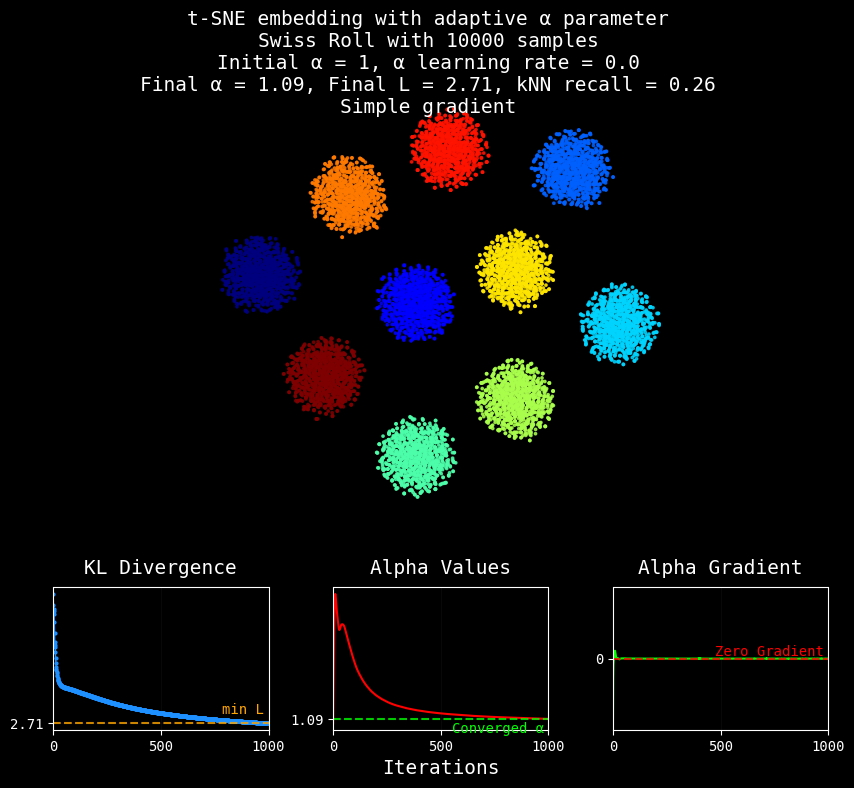

In [ ]:
fig = plot_tsne_result(tsne_result, y, f"Gaussian {n_dim}D", black_template=True)
fig.savefig(results_path / f"run_{run}.png", dpi=300)

In [ ]:
# ensure the n_dim dict exists
RESULTS.setdefault(n_dim, {})

# ensure the run dict exists
RESULTS[n_dim].setdefault(f"run_{run}", {})

# now write values
RESULTS[n_dim][f"run_{run}"]["optimal_dof"] = round(float(tsne_result.im_alphas[-1]), 4)
RESULTS[n_dim][f"run_{run}"]["KL"] = round(float(tsne_result.im_KLs[-1]), 4)
RESULTS[n_dim][f"run_{run}"]["alpha_grad"] = round(
    float(tsne_result.im_alpha_grads[-1]), 4
)
print(json.dumps(RESULTS, indent=4))

## 10 Dimensions

In [60]:
n_dim = 10

results_path = base_results_path / f"{n_dim}_dim"
results_path.mkdir(exist_ok=True)

### Run 1

In [61]:
run = 1
X, y, centers = generate_separated_gaussian_clusters(
    n_clusters=10,
    points_per_cluster=1000,
    dim=n_dim,
    sigma=sigma,
    q=q,
    seed=run,  # tie random seed to run for reproducibility
)
print("Generated data shape:", X.shape)

Generated data shape: (10000, 10)


In [ ]:
tsne_result: TSNEResult = run_tsne(
    X,
    perplexity=perplexity,
    random_state=None,
    n_components=n_components,
    n_iter=n_iter,
    n_jobs=n_jobs,
    initial_dof=initial_alpha,
    dof="auto",
    negative_gradient_method="bh",
    dataset_name=dataset_name,
    affinities_type = affinities_type
)

Performing the early exaggeration fase with exaggeration = 12 and learning rate = 833.33 for 250 iterations...
===> Running optimization with exaggeration=12.00, lr=833.33 for 250 iterations...
Iteration   50, KL divergence 4.0690, DoF 1.0000, DoF gradient 0.0000, 50 iterations in 0.8796 sec
Iteration  100, KL divergence 3.9104, DoF 1.0000, DoF gradient 0.0000, 50 iterations in 1.0219 sec
Iteration  150, KL divergence 3.8540, DoF 1.0000, DoF gradient 0.0000, 50 iterations in 0.9325 sec
Iteration  200, KL divergence 3.8249, DoF 1.0000, DoF gradient 0.0000, 50 iterations in 1.0136 sec
Iteration  250, KL divergence 3.8068, DoF 1.0000, DoF gradient 0.0000, 50 iterations in 0.9848 sec
   --> Time elapsed: 4.83 seconds
===> Running optimization with exaggeration=1.00, lr=10000.00 for 1000 iterations...
Iteration   50, KL divergence 2.7353, DoF 2.5834, DoF gradient -0.0200, 50 iterations in 1.7454 sec
Iteration  100, KL divergence 2.6442, DoF 1.8603, DoF gradient -0.0089, 50 iterations in 1.7

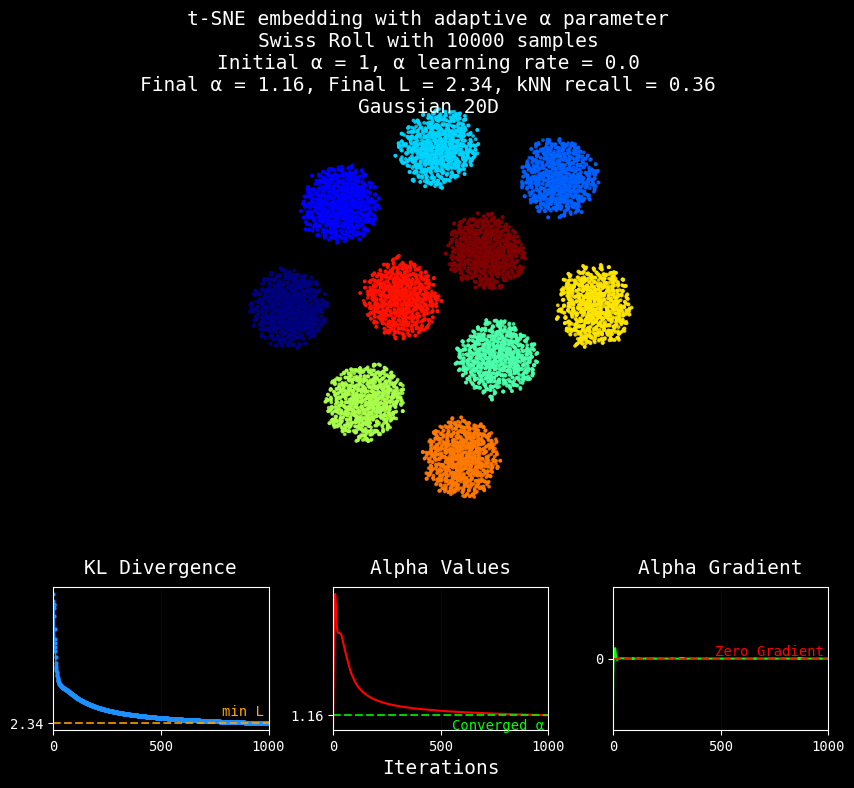

In [ ]:
fig = plot_tsne_result(tsne_result, y, f"Gaussian {n_dim}D", black_template=True)
fig.savefig(results_path / f"run_{run}.png", dpi=300)

In [64]:
# ensure the n_dim dict exists
RESULTS.setdefault(n_dim, {})

# ensure the run dict exists
RESULTS[n_dim].setdefault(f"run_{run}", {})

# now write values
RESULTS[n_dim][f"run_{run}"]["optimal_dof"] = round(float(tsne_result.im_alphas[-1]), 4)
RESULTS[n_dim][f"run_{run}"]["KL"] = round(float(tsne_result.im_KLs[-1]), 4)
RESULTS[n_dim][f"run_{run}"]["alpha_grad"] = round(
    float(tsne_result.im_alpha_grads[-1]), 4
)
print(json.dumps(RESULTS, indent=4))

{20: {'run_2': {'optimal_dof': 1.0906, 'KL': 2.7037, 'alpha_grad': -0.0002}, 'run_1': {'optimal_dof': 1.0943, 'KL': 2.7093, 'alpha_grad': -0.0003}, 'run_3': {'optimal_dof': 1.0902, 'KL': 2.7049, 'alpha_grad': 0.0001}}, 10: {'run_1': {'optimal_dof': 1.1635, 'KL': 2.3356, 'alpha_grad': -0.0001}}}


## 5 Dimensions

In [81]:
n_dim = 5
results_path = base_results_path / f"{n_dim}_dim"
results_path.mkdir(exist_ok=True)

### Run 1

In [82]:
run = 1
X, y, centers = generate_separated_gaussian_clusters(
    n_clusters=10,
    points_per_cluster=1000,
    dim=n_dim,
    sigma=sigma,
    q=q,
    seed=run,  # tie random seed to run for reproducibility
)
print("Generated data shape:", X.shape)

Generated data shape: (10000, 5)


In [ ]:
tsne_result: TSNEResult = run_tsne(
    X,
    perplexity=perplexity,
    random_state=None,
    n_components=n_components,
    n_iter=n_iter,
    n_jobs=n_jobs,
    initial_dof=initial_alpha,
    dof="auto",
    negative_gradient_method="bh",
    dataset_name=dataset_name,
    affinities_type = affinities_type
)

Performing the early exaggeration fase with exaggeration = 12 and learning rate = 833.33 for 250 iterations...
===> Running optimization with exaggeration=12.00, lr=833.33 for 250 iterations...
Iteration   50, KL divergence 4.1707, DoF 1.0000, DoF gradient 0.0000, 50 iterations in 0.8214 sec
Iteration  100, KL divergence 4.0149, DoF 1.0000, DoF gradient 0.0000, 50 iterations in 0.9719 sec
Iteration  150, KL divergence 3.9466, DoF 1.0000, DoF gradient 0.0000, 50 iterations in 1.1951 sec
Iteration  200, KL divergence 3.9141, DoF 1.0000, DoF gradient 0.0000, 50 iterations in 1.0458 sec
Iteration  250, KL divergence 3.8946, DoF 1.0000, DoF gradient 0.0000, 50 iterations in 1.0684 sec
   --> Time elapsed: 5.11 seconds
===> Running optimization with exaggeration=1.00, lr=10000.00 for 1000 iterations...
Iteration   50, KL divergence 2.0964, DoF 2.7624, DoF gradient -0.0239, 50 iterations in 2.0283 sec
Iteration  100, KL divergence 1.9516, DoF 2.0387, DoF gradient -0.0066, 50 iterations in 1.7

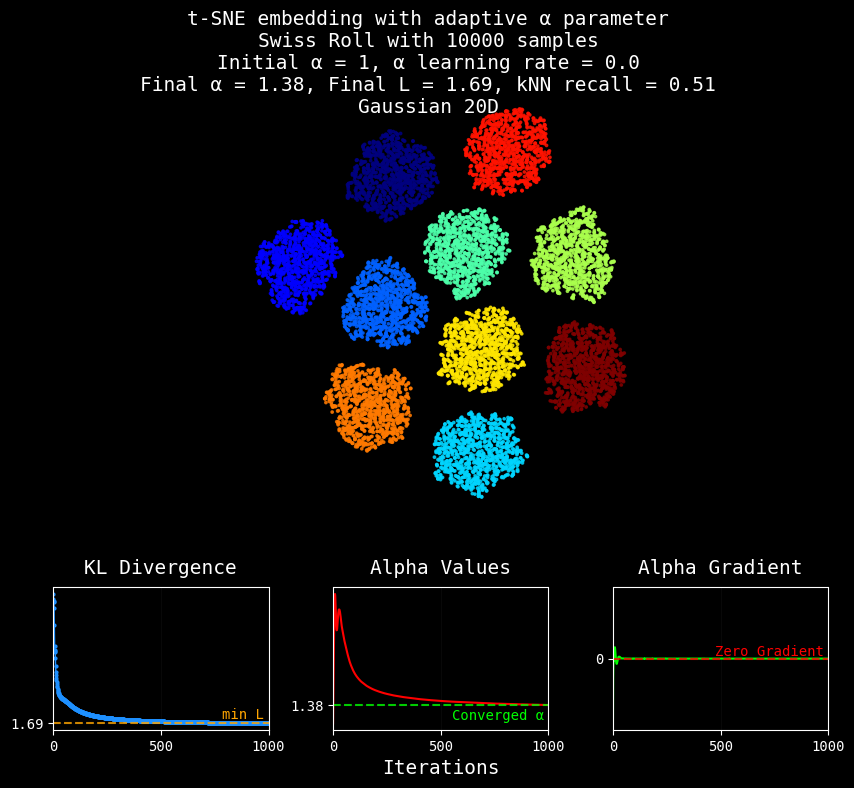

In [ ]:
fig = plot_tsne_result(tsne_result, y, f"Gaussian {n_dim}D", black_template=True)
fig.savefig(results_path / f"run_{run}.png", dpi=300)

In [85]:
# ensure the n_dim dict exists
RESULTS.setdefault(n_dim, {})

# ensure the run dict exists
RESULTS[n_dim].setdefault(f"run_{run}", {})

# now write values
RESULTS[n_dim][f"run_{run}"]["optimal_dof"] = round(float(tsne_result.im_alphas[-1]), 4)
RESULTS[n_dim][f"run_{run}"]["KL"] = round(float(tsne_result.im_KLs[-1]), 4)
RESULTS[n_dim][f"run_{run}"]["alpha_grad"] = round(
    float(tsne_result.im_alpha_grads[-1]), 4
)
print(json.dumps(RESULTS, indent=4))

{
    "20": {
        "run_2": {
            "optimal_dof": 1.0906,
            "KL": 2.7037,
            "alpha_grad": -0.0002
        },
        "run_1": {
            "optimal_dof": 1.0943,
            "KL": 2.7093,
            "alpha_grad": -0.0003
        },
        "run_3": {
            "optimal_dof": 1.0902,
            "KL": 2.7049,
            "alpha_grad": 0.0001
        }
    },
    "10": {
        "run_1": {
            "optimal_dof": 1.1647,
            "KL": 2.3322,
            "alpha_grad": 0.0
        },
        "run_2": {
            "optimal_dof": 1.1717,
            "KL": 2.3258,
            "alpha_grad": 0.0001
        },
        "run_3": {
            "optimal_dof": 1.1684,
            "KL": 2.3249,
            "alpha_grad": 0.0002
        }
    },
    "5": {
        "run_1": {
            "optimal_dof": 1.378,
            "KL": 1.6948,
            "alpha_grad": 0.0
        }
    }
}


## 2 Dimensions

In [95]:
n_dim = 2
results_path = base_results_path / f"{n_dim}_dim"
results_path.mkdir(exist_ok=True)

### Run 1

In [97]:
run = 1
X, y, centers = generate_separated_gaussian_clusters(
    n_clusters=10,
    points_per_cluster=1000,
    dim=n_dim,
    sigma=sigma,
    q=q,
    seed=run,  # tie random seed to run for reproducibility
)
print("Generated data shape:", X.shape)

Generated data shape: (10000, 2)


In [ ]:
tsne_result: TSNEResult = run_tsne(
    X,
    perplexity=perplexity,
    random_state=None,
    n_components=n_components,
    n_iter=n_iter,
    n_jobs=n_jobs,
    initial_dof=initial_alpha,
    dof="auto",
    negative_gradient_method="bh",
    dataset_name=dataset_name,
    affinities_type = affinities_type
)

Performing the early exaggeration fase with exaggeration = 12 and learning rate = 833.33 for 250 iterations...
===> Running optimization with exaggeration=12.00, lr=833.33 for 250 iterations...
Iteration   50, KL divergence 3.7862, DoF 1.0000, DoF gradient 0.0000, 50 iterations in 0.9639 sec
Iteration  100, KL divergence 3.3853, DoF 1.0000, DoF gradient 0.0000, 50 iterations in 0.9522 sec
Iteration  150, KL divergence 3.1657, DoF 1.0000, DoF gradient 0.0000, 50 iterations in 0.8985 sec
Iteration  200, KL divergence 3.0564, DoF 1.0000, DoF gradient 0.0000, 50 iterations in 0.8911 sec
Iteration  250, KL divergence 2.9895, DoF 1.0000, DoF gradient 0.0000, 50 iterations in 0.8845 sec
   --> Time elapsed: 4.59 seconds
===> Running optimization with exaggeration=1.00, lr=10000.00 for 1000 iterations...
Iteration   50, KL divergence 0.3784, DoF 14.3345, DoF gradient 0.1205, 50 iterations in 1.7282 sec
Iteration  100, KL divergence 0.2930, DoF 18.4098, DoF gradient 0.0484, 50 iterations in 1.8

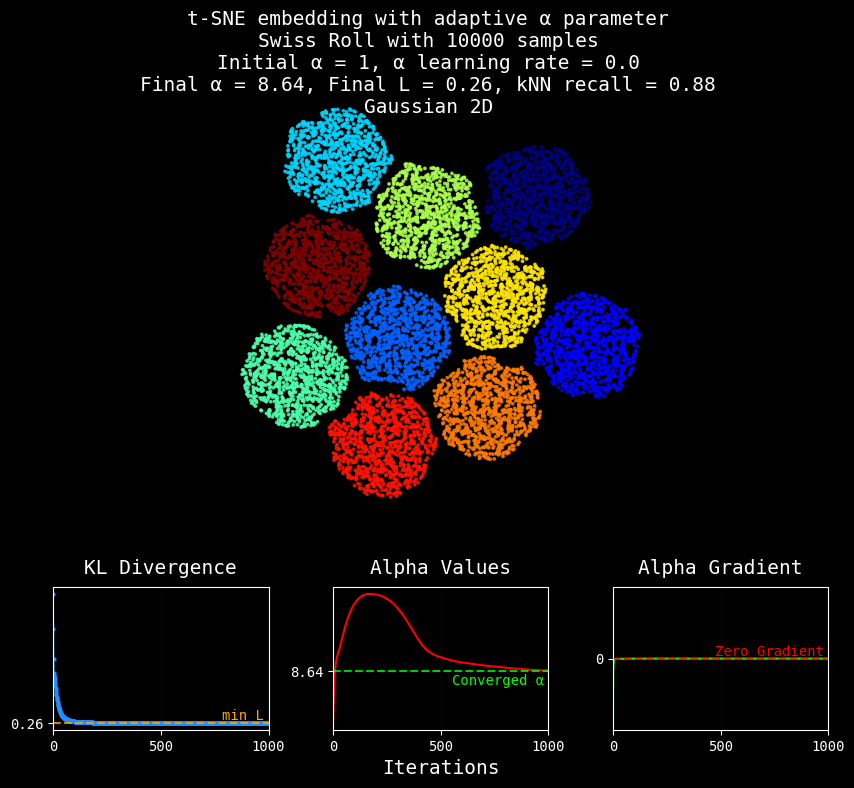

In [99]:
fig = plot_tsne_result(tsne_result, y, f"Gaussian {n_dim}D", black_template=True)
fig.savefig(results_path / f"run_{run}.png", dpi=300)

In [100]:
# ensure the n_dim dict exists
RESULTS.setdefault(n_dim, {})

# ensure the run dict exists
RESULTS[n_dim].setdefault(f"run_{run}", {})

# now write values
RESULTS[n_dim][f"run_{run}"]["optimal_dof"] = round(float(tsne_result.im_alphas[-1]), 4)
RESULTS[n_dim][f"run_{run}"]["KL"] = round(float(tsne_result.im_KLs[-1]), 4)
RESULTS[n_dim][f"run_{run}"]["alpha_grad"] = round(
    float(tsne_result.im_alpha_grads[-1]), 4
)
print(json.dumps(RESULTS, indent=4))

{
    "20": {
        "run_2": {
            "optimal_dof": 1.0906,
            "KL": 2.7037,
            "alpha_grad": -0.0002
        },
        "run_1": {
            "optimal_dof": 1.0943,
            "KL": 2.7093,
            "alpha_grad": -0.0003
        },
        "run_3": {
            "optimal_dof": 1.0902,
            "KL": 2.7049,
            "alpha_grad": 0.0001
        }
    },
    "10": {
        "run_1": {
            "optimal_dof": 1.1647,
            "KL": 2.3322,
            "alpha_grad": 0.0
        },
        "run_2": {
            "optimal_dof": 1.1717,
            "KL": 2.3258,
            "alpha_grad": 0.0001
        },
        "run_3": {
            "optimal_dof": 1.1684,
            "KL": 2.3249,
            "alpha_grad": 0.0002
        }
    },
    "5": {
        "run_1": {
            "optimal_dof": 1.378,
            "KL": 1.6948,
            "alpha_grad": 0.0
        },
        "run_2": {
            "optimal_dof": 1.377,
            "KL": 1.6767,
         

# Uniform Affinities

## 20 Dimensions

In [132]:
base_results_path = Path("gaussian_blobs_experiment_results/uniform_affinities")
base_results_path.mkdir(exist_ok=True)
RESULTS = {}

In [133]:
affinities_type = "uniform"
n_iter = 2000

In [134]:
n_dim = 20

In [135]:
run = 1
X, y, centers = generate_separated_gaussian_clusters(
    n_clusters=10,
    points_per_cluster=1000,
    dim=n_dim,
    sigma=sigma,
    q=q,
    seed=run,  # tie random seed to run for reproducibility
)
print("Generated data shape:", X.shape)

Generated data shape: (10000, 20)


In [136]:
tsne_result: TSNEResult = run_tsne(
    X,
    perplexity=perplexity,
    random_state=None,
    n_components=n_components,
    n_iter=n_iter,
    n_jobs=n_jobs,
    initial_dof=initial_alpha,
    dof="auto",
    negative_gradient_method="bh",
    dataset_name=dataset_name,
    affinities_type=affinities_type,
)

Performing the early exaggeration fase with exaggeration = 12 and learning rate = 833.33 for 250 iterations...
===> Running optimization with exaggeration=12.00, lr=833.33 for 250 iterations...
Iteration   50, KL divergence 3.4233, DoF 1.0000, DoF gradient 0.0000, 50 iterations in 0.8930 sec
Iteration  100, KL divergence 3.3081, DoF 1.0000, DoF gradient 0.0000, 50 iterations in 0.9155 sec
Iteration  150, KL divergence 3.2559, DoF 1.0000, DoF gradient 0.0000, 50 iterations in 0.8978 sec
Iteration  200, KL divergence 3.2250, DoF 1.0000, DoF gradient 0.0000, 50 iterations in 0.9198 sec
Iteration  250, KL divergence 3.2068, DoF 1.0000, DoF gradient 0.0000, 50 iterations in 0.9134 sec
   --> Time elapsed: 4.54 seconds
===> Running optimization with exaggeration=1.00, lr=10000.00 for 2000 iterations...
Iteration   50, KL divergence 2.7173, DoF 5.3535, DoF gradient 0.0578, 50 iterations in 1.5684 sec
Iteration  100, KL divergence 2.7102, DoF 8.0775, DoF gradient 0.0511, 50 iterations in 1.542

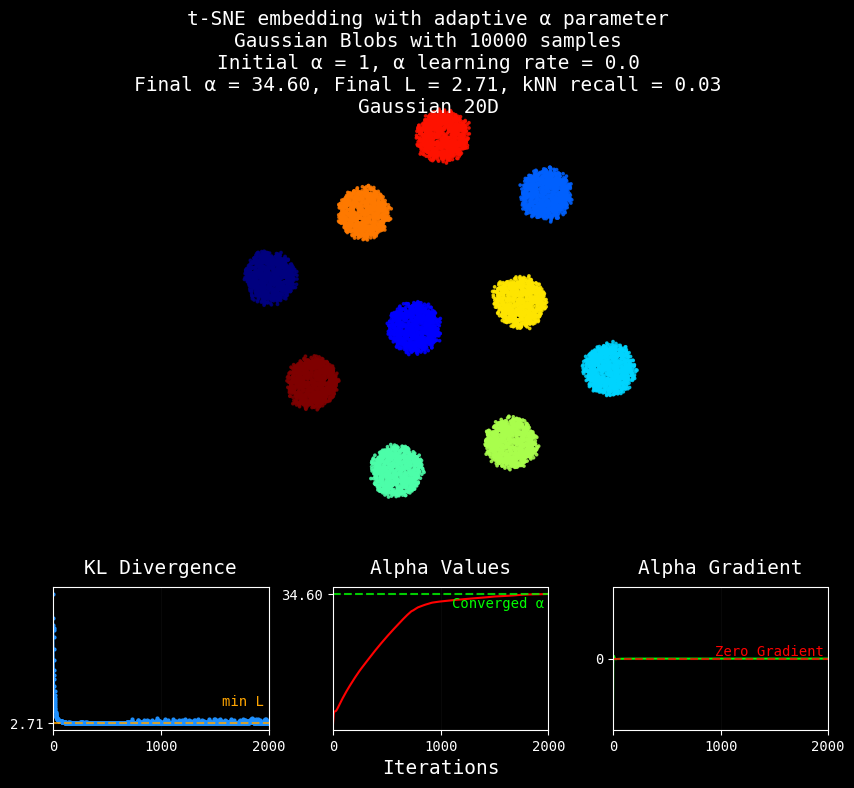

In [137]:
fig = plot_tsne_result(tsne_result, y, f"Gaussian {n_dim}D", black_template=True)
fig.savefig(results_path / f"run_{run}.png", dpi=300)

In [145]:
# ensure the n_dim dict exists
RESULTS.setdefault(n_dim, {})

# ensure the run dict exists
RESULTS[n_dim].setdefault(f"run_{run}", {})

# now write values
RESULTS[n_dim][f"run_{run}"]["optimal_dof"] = round(float(tsne_result.im_alphas[-1]), 4)
RESULTS[n_dim][f"run_{run}"]["KL"] = round(float(tsne_result.im_KLs[-1]), 4)
RESULTS[n_dim][f"run_{run}"]["alpha_grad"] = round(
    float(tsne_result.im_alpha_grads[-1]), 4
)
print(json.dumps(RESULTS, indent=4))

{
    "20": {
        "run_1": {
            "optimal_dof": 34.6021,
            "KL": 2.7077,
            "alpha_grad": -0.0
        }
    }
}


# Cumulative Experiment

## Set Up

### Shared Parameters

In [6]:
# Gaussian blobls parameters
n_clusters = 10
points_per_cluster = 1000
sigma = 2
q = 0.95

# TSNE parameters
perplexity = 20
n_jobs = 1
n_components = 2
n_iter = 1000
dof_lr = 1
n_jobs = -1
initial_alpha = 1
dataset_name = "Gaussian Blobs"

### PerplexityBasedNN

In [ ]:
base_results_path = Path("gaussian_blobs_experiment_results/PerplexityBasedNN")
base_results_path.mkdir(exist_ok=True)
RESULTS = {}

affinities_type = "perplexity"
dims = [20, 10, 5, 2]


runs = range(1, 5)

for n_dim in tqdm(dims, desc="Data Dimensionality"):
    results_path = base_results_path / f"{n_dim}_dim"
    results_path.mkdir(exist_ok=True)
    RESULTS.setdefault(n_dim, {})
    for run in tqdm(runs, desc=f"Runs for {n_dim}D", leave=False):
        RESULTS[n_dim].setdefault(f"run_{run}", {})
        X, y, centers = generate_separated_gaussian_clusters(
            n_clusters=n_clusters,
            points_per_cluster=points_per_cluster,
            dim=n_dim,
            sigma=sigma,
            q=q,
            seed=run,  # tie random seed to run for reproducibility
        )
        tsne_result: TSNEResult = run_tsne(
            X,
            perplexity=perplexity,
            random_state=None,
            n_components=n_components,
            n_iter=n_iter,
            n_jobs=n_jobs,
            initial_dof=initial_alpha,
            dof="auto",
            negative_gradient_method="bh",
            dataset_name=dataset_name,
            affinities_type=affinities_type,
            verbose=True,
        )
        fig = plot_tsne_result(
            tsne_result, y, f"{n_dim}D", black_template=True, show_figure=False
        )
        fig.savefig(results_path / f"run_{run}.png", dpi=300)

        # now write values
        RESULTS[n_dim][f"run_{run}"]["optimal_dof"] = round(
            float(tsne_result.im_alphas[-1]), 4
        )
        RESULTS[n_dim][f"run_{run}"]["KL"] = round(float(tsne_result.im_KLs[-1]), 4)
        RESULTS[n_dim][f"run_{run}"]["alpha_grad"] = round(
            float(tsne_result.im_alpha_grads[-1]), 4
        )
        with Path(
            base_results_path / f"overall_results_{affinities_type}_affinities.json"
        ).open("w") as f:
            json.dump(RESULTS, f, indent=4)

### Uniform Affinities

In [ ]:
base_results_path = Path("gaussian_blobs_experiment_results/uniform_affinities")
base_results_path.mkdir(exist_ok=True)
RESULTS = {}

affinities_type = "uniform"
dims = [20, 10, 5, 2]


runs = range(1, 5)

for n_dim in tqdm(dims, desc="Data Dimensionality"):
    results_path = base_results_path / f"{n_dim}_dim"
    results_path.mkdir(exist_ok=True)
    RESULTS.setdefault(n_dim, {})
    for run in runs:
        RESULTS[n_dim].setdefault(f"run_{run}", {})
        X, y, centers = generate_separated_gaussian_clusters(
            n_clusters=n_clusters,
            points_per_cluster=points_per_cluster,
            dim=n_dim,
            sigma=sigma,
            q=q,
            seed=run,  # tie random seed to run for reproducibility
        )
        tsne_result: TSNEResult = run_tsne(
            X,
            perplexity=perplexity,
            random_state=None,
            n_components=n_components,
            n_iter=n_iter,
            n_jobs=n_jobs,
            initial_dof=initial_alpha,
            dof="auto",
            negative_gradient_method="bh",
            dataset_name=dataset_name,
            affinities_type=affinities_type,
            verbose=True,
        )
        fig = plot_tsne_result(
            tsne_result, y, f"{n_dim}D", black_template=True, show_figure=False
        )
        fig.savefig(results_path / f"run_{run}.png", dpi=300)

        # now write values
        RESULTS[n_dim][f"run_{run}"]["optimal_dof"] = round(
            float(tsne_result.im_alphas[-1]), 4
        )
        RESULTS[n_dim][f"run_{run}"]["KL"] = round(float(tsne_result.im_KLs[-1]), 4)
        RESULTS[n_dim][f"run_{run}"]["alpha_grad"] = round(
            float(tsne_result.im_alpha_grads[-1]), 4
        )
        with Path(
            base_results_path / f"overall_results_{affinities_type}_affinities.json"
        ).open("w") as f:
            json.dump(RESULTS, f, indent=4)

## Results

### PerplexityBasedNN

In [5]:
path = "gaussian_blobs_experiment_results/PerplexityBasedNN/overall_results_perplexity_affinities.json"
with Path(path).open() as f:
    loaded_results = json.load(f)

Text(0, 0.5, 'Optimal DoF')

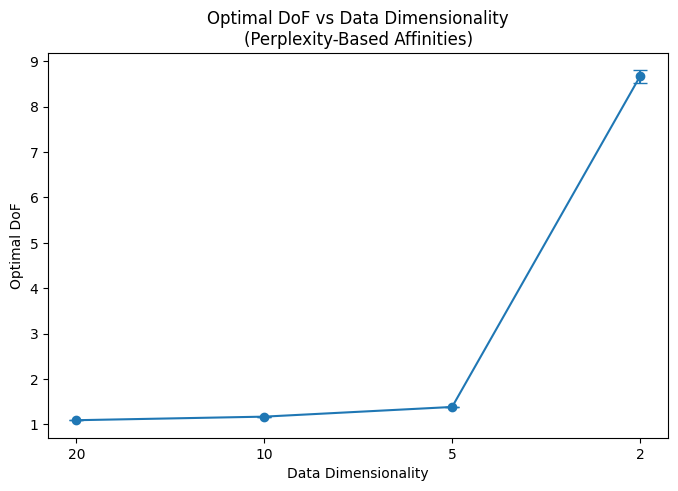

In [6]:
dims = [20, 10, 5, 2]
runs = range(1, 5)

optimal_dofs = [
    [loaded_results[str(dim)][f"run_{run}"]["optimal_dof"] for run in runs]
    for dim in dims
]

fig, ax = plt.subplots(figsize=(8, 5))
ax.errorbar(
    [str(dim) for dim in dims],
    [np.mean(optimal_dofs[i]) for i in range(len(dims))],
    yerr=[np.std(optimal_dofs[i]) for i in range(len(dims))],
    fmt="-o",
    capsize=5,
)
ax.set_title("Optimal DoF vs Data Dimensionality\n(Perplexity-Based Affinities)")
ax.set_xlabel("Data Dimensionality")
ax.set_ylabel("Optimal DoF")

Text(0, 0.5, 'KL Divergence')

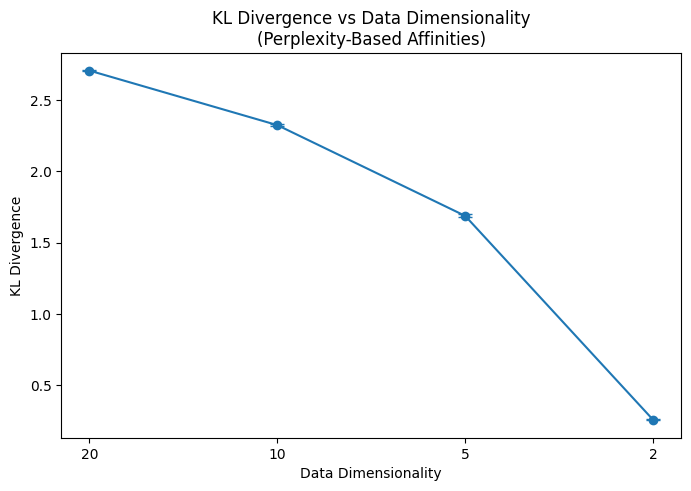

In [7]:
dims = [20, 10, 5, 2]
runs = range(1, 5)

kl_divergences = [
    [loaded_results[str(dim)][f"run_{run}"]["KL"] for run in runs] for dim in dims
]

fig, ax = plt.subplots(figsize=(8, 5))
ax.errorbar(
    [str(dim) for dim in dims],
    [np.mean(kl_divergences[i]) for i in range(len(dims))],
    yerr=[np.std(kl_divergences[i]) for i in range(len(dims))],
    fmt="-o",
    capsize=5,
)
ax.set_title("KL Divergence vs Data Dimensionality\n(Perplexity-Based Affinities)")
ax.set_xlabel("Data Dimensionality")
ax.set_ylabel("KL Divergence")

### Uniform affinities

In [8]:
path = "gaussian_blobs_experiment_results/uniform_affinities/overall_results_uniform_affinities.json"
with Path(path).open() as f:
    loaded_results = json.load(f)

Text(0, 0.5, 'Optimal DoF')

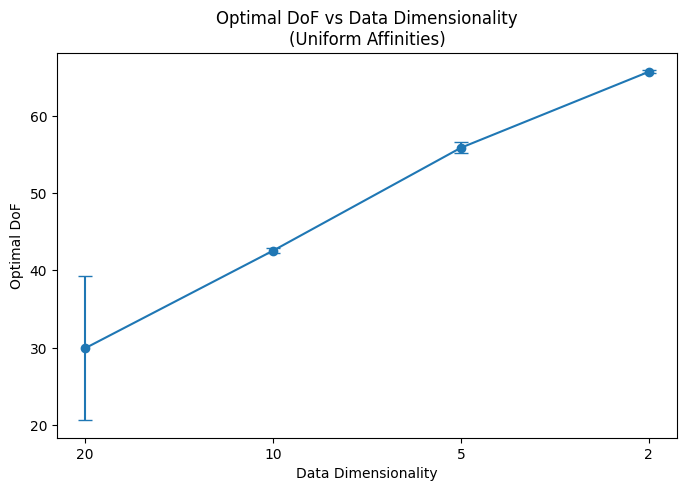

In [9]:
dims = [20, 10, 5, 2]
runs = range(1, 5)

optimal_dofs = [
    [loaded_results[str(dim)][f"run_{run}"]["optimal_dof"] for run in runs]
    for dim in dims
]

fig, ax = plt.subplots(figsize=(8, 5))
ax.errorbar(
    [str(dim) for dim in dims],
    [np.mean(optimal_dofs[i]) for i in range(len(dims))],
    yerr=[np.std(optimal_dofs[i]) for i in range(len(dims))],
    fmt="-o",
    capsize=5,
)
ax.set_title("Optimal DoF vs Data Dimensionality\n(Uniform Affinities)")
ax.set_xlabel("Data Dimensionality")
ax.set_ylabel("Optimal DoF")

Text(0, 0.5, 'KL Divergence')

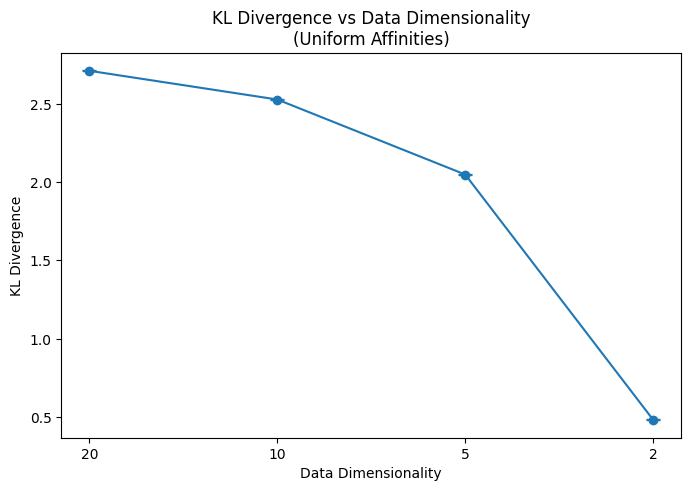

In [10]:
dims = [20, 10, 5, 2]
runs = range(1, 5)

kl_divergences = [
    [loaded_results[str(dim)][f"run_{run}"]["KL"] for run in runs] for dim in dims
]

fig, ax = plt.subplots(figsize=(8, 5))
ax.errorbar(
    [str(dim) for dim in dims],
    [np.mean(kl_divergences[i]) for i in range(len(dims))],
    yerr=[np.std(kl_divergences[i]) for i in range(len(dims))],
    fmt="-o",
    capsize=5,
)
ax.set_title("KL Divergence vs Data Dimensionality\n(Uniform Affinities)")
ax.set_xlabel("Data Dimensionality")
ax.set_ylabel("KL Divergence")

# Fake Edges in 2D

## Set Up

In [ ]:
import scipy.sparse as sp

from openTSNE import TSNE, TSNEEmbedding
from openTSNE.affinity import PerplexityBasedNN, Uniform, PrecomputedAffinities
from openTSNE.initialization import pca

In [ ]:
def inject_false_edges_into_P(
    P: sp.csr_matrix,
    p_inject: float,
    *,
    strength: float = 0.1,
    symmetric: bool = True,
    renormalize: bool = True,
    seed: int | None = None,
) -> sp.csr_matrix:
    """
    Inject random non-neighbor connections into a sparse affinity matrix P.

    Parameters
    ----------
    P : scipy.sparse.csr_matrix, shape (n, n)
        Sparse affinity matrix (typically from perplexity-based kNN). Usually
        symmetric and globally normalized (sum(P) ~= 1) when built with
        symmetrize=True in openTSNE.
    p_inject : float
        Fraction of new edges to add per row, relative to the current number of
        nonzeros in that row. For example, p_inject=0.2 adds ~20% more edges.
    strength : float, default=0.1
        Weight of injected edges relative to a row scale. Here we use
        `strength * min_nonzero_in_row` as the injected weight.
    symmetric : bool, default=True
        If True, enforce symmetry after injection via (P + P.T)/2.
    renormalize : bool, default=True
        If True, globally renormalize so that sum(P) == 1.
    seed : int or None
        RNG seed.

    Returns
    -------
    P_corrupt : scipy.sparse.csr_matrix
        Corrupted affinity matrix.
    """
    if not sp.isspmatrix_csr(P):
        P = P.tocsr()

    if not (0.0 <= p_inject):
        raise ValueError("p_inject must be >= 0")

    rng = np.random.default_rng(seed)
    n = P.shape[0]

    # Use LIL for efficient incremental updates
    P_lil = P.tolil(copy=True)

    for i in range(n):
        row_cols = P.indices[P.indptr[i] : P.indptr[i + 1]]
        row_data = P.data[P.indptr[i] : P.indptr[i + 1]]

        k_row = len(row_cols)
        if k_row == 0:
            continue

        m = int(np.round(p_inject * k_row))
        if m <= 0:
            continue

        # Determine a sensible small weight for injected edges
        # (ignore zeros; row_data should be nonzero already)
        row_min = float(np.min(row_data))
        w = strength * row_min

        # Sample candidate j's that are not already neighbors and not self.
        # We'll do rejection sampling in batches to avoid building a full complement set.
        existing = set(row_cols.tolist())
        existing.add(i)

        new_js = []
        # oversample to reduce loops
        while len(new_js) < m:
            cand = rng.integers(0, n, size=4 * (m - len(new_js)))
            for j in cand:
                j = int(j)
                if j not in existing:
                    existing.add(j)
                    new_js.append(j)
                    if len(new_js) == m:
                        break

        # Add injected edges
        for j in new_js:
            P_lil[i, j] = (
                P_lil[i, j] + w
            )  # accumulate if already present (shouldn't be)

    P_corrupt = P_lil.tocsr()

    if symmetric:
        P_corrupt = 0.5 * (P_corrupt + P_corrupt.T)

    if renormalize:
        s = P_corrupt.sum()
        if s != 0:
            P_corrupt = P_corrupt / s

    return P_corrupt

In [80]:
def make_precomputed_affinities(P_corr, *, symmetrize=True, normalize=True):
    """
    Wrap a (possibly corrupted) affinity matrix P into an openTSNE Affinities object.
    """
    if not sp.isspmatrix(P_corr):
        raise TypeError("P_corr must be a scipy sparse matrix")
    P_corr = P_corr.tocsr()

    if symmetrize:
        P_corr = 0.5 * (P_corr + P_corr.T)

    if normalize:
        s = P_corr.sum()
        if s <= 0:
            raise ValueError("P_corr has non-positive sum; cannot normalize")
        P_corr = P_corr / s

    return PrecomputedAffinities(P_corr)

In [81]:
n_dim = 2
run = 1
X, y, centers = generate_separated_gaussian_clusters(
    n_clusters=10,
    points_per_cluster=1000,
    dim=n_dim,
    sigma=sigma,
    q=q,
    seed=run,  # tie random seed to run for reproducibility
)
print("Generated data shape:", X.shape)

Generated data shape: (10000, 2)


In [68]:
affinities_obj = PerplexityBasedNN(
    data=X,
    perplexity=perplexity,
    metric="euclidean",
    random_state=42,
)

In [82]:
P_clean = affinities_obj.P

In [89]:
p_corr = inject_false_edges_into_P(P_clean, p_inject=0.2, strength=1)

In [90]:
pre_computed = make_precomputed_affinities(p_corr)

In [91]:
tsne_result: TSNEResult = run_tsne(
    X,
    perplexity=perplexity,
    random_state=None,
    n_components=n_components,
    n_iter=1000,
    n_jobs=n_jobs,
    initial_dof=initial_alpha,
    dof="auto",
    negative_gradient_method="bh",
    dataset_name=dataset_name,
    pre_computed_affinities=pre_computed,
    verbose=True,
)

Performing the early exaggeration fase with exaggeration = 12 and learning rate = 833.33 for 250 iterations...
===> Running optimization with exaggeration=12.00, lr=833.33 for 250 iterations...
Iteration   50, KL divergence 3.7958, DoF 1.0000, DoF gradient 0.0000, 50 iterations in 1.0858 sec
Iteration  100, KL divergence 3.3878, DoF 1.0000, DoF gradient 0.0000, 50 iterations in 0.9433 sec
Iteration  150, KL divergence 3.1677, DoF 1.0000, DoF gradient 0.0000, 50 iterations in 0.9259 sec
Iteration  200, KL divergence 3.0583, DoF 1.0000, DoF gradient 0.0000, 50 iterations in 0.9220 sec
Iteration  250, KL divergence 2.9910, DoF 1.0000, DoF gradient 0.0000, 50 iterations in 0.9181 sec
   --> Time elapsed: 4.80 seconds
===> Running optimization with exaggeration=1.00, lr=10000.00 for 1000 iterations...
Iteration   50, KL divergence 0.3877, DoF 13.4893, DoF gradient 0.0915, 50 iterations in 1.7883 sec
Iteration  100, KL divergence 0.3022, DoF 15.2850, DoF gradient -0.0029, 50 iterations in 1.

Performing the early exaggeration fase with exaggeration = 12 and learning rate = 833.33 for 250 iterations...
===> Running optimization with exaggeration=12.00, lr=833.33 for 250 iterations...
Iteration   50, KL divergence 3.8828, DoF 1.0000, DoF gradient 0.0000, 50 iterations in 0.8455 sec
Iteration  100, KL divergence 3.3874, DoF 1.0000, DoF gradient 0.0000, 50 iterations in 0.8739 sec
Iteration  150, KL divergence 3.1714, DoF 1.0000, DoF gradient 0.0000, 50 iterations in 0.8590 sec
Iteration  200, KL divergence 3.0629, DoF 1.0000, DoF gradient 0.0000, 50 iterations in 0.9174 sec
Iteration  250, KL divergence 2.9961, DoF 1.0000, DoF gradient 0.0000, 50 iterations in 0.9070 sec
   --> Time elapsed: 4.40 seconds
===> Running optimization with exaggeration=1.00, lr=10000.00 for 1000 iterations...
Iteration   50, KL divergence 0.3760, DoF 14.4211, DoF gradient 0.1199, 50 iterations in 1.7033 sec
Iteration  100, KL divergence 0.2967, DoF 18.3267, DoF gradient 0.0446, 50 iterations in 1.7

c:\Users\bythe\Documents\Repos\openTSNE_fork_fresh\openTSNE\examples\plot_utils.py:12: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  data: TSNEResult,


Performing the early exaggeration fase with exaggeration = 12 and learning rate = 833.33 for 250 iterations...
===> Running optimization with exaggeration=12.00, lr=833.33 for 250 iterations...
Iteration   50, KL divergence 3.8104, DoF 1.0000, DoF gradient 0.0000, 50 iterations in 0.9277 sec
Iteration  100, KL divergence 3.3910, DoF 1.0000, DoF gradient 0.0000, 50 iterations in 0.9227 sec
Iteration  150, KL divergence 3.1691, DoF 1.0000, DoF gradient 0.0000, 50 iterations in 0.9210 sec
Iteration  200, KL divergence 3.0591, DoF 1.0000, DoF gradient 0.0000, 50 iterations in 0.9281 sec
Iteration  250, KL divergence 2.9917, DoF 1.0000, DoF gradient 0.0000, 50 iterations in 0.8924 sec
   --> Time elapsed: 4.59 seconds
===> Running optimization with exaggeration=1.00, lr=10000.00 for 1000 iterations...
Iteration   50, KL divergence 0.3893, DoF 13.5423, DoF gradient 0.0891, 50 iterations in 1.8470 sec
Iteration  100, KL divergence 0.3030, DoF 15.3193, DoF gradient -0.0025, 50 iterations in 1.

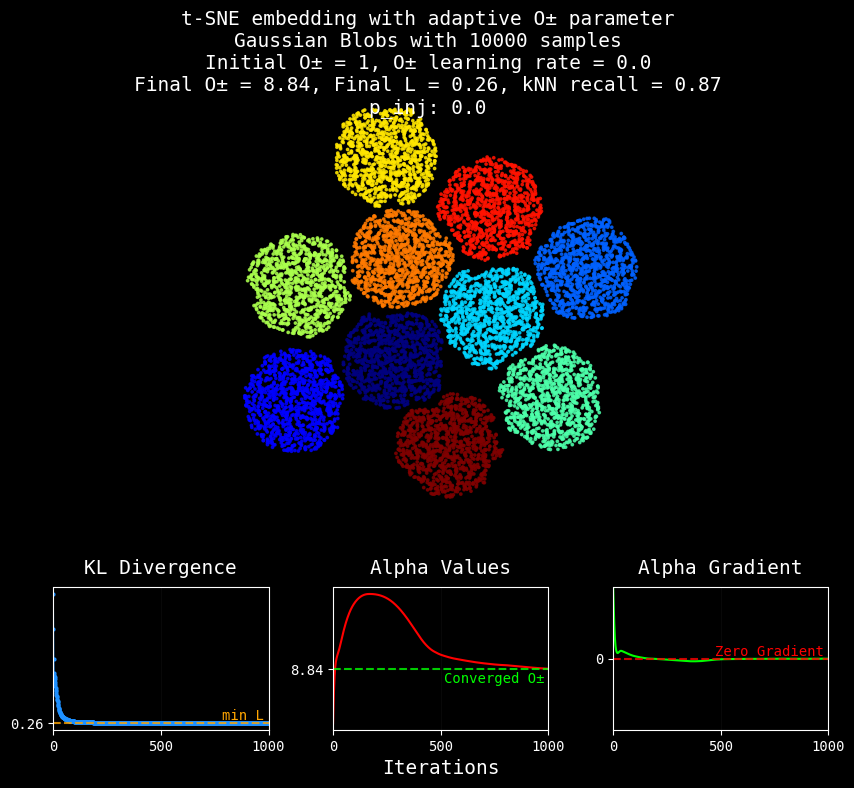

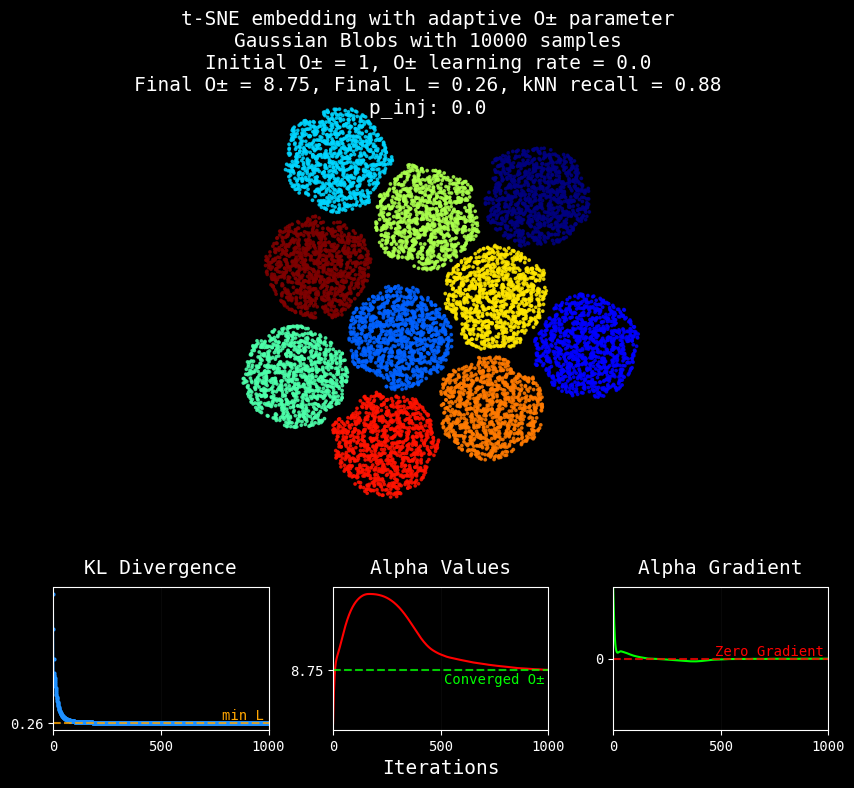

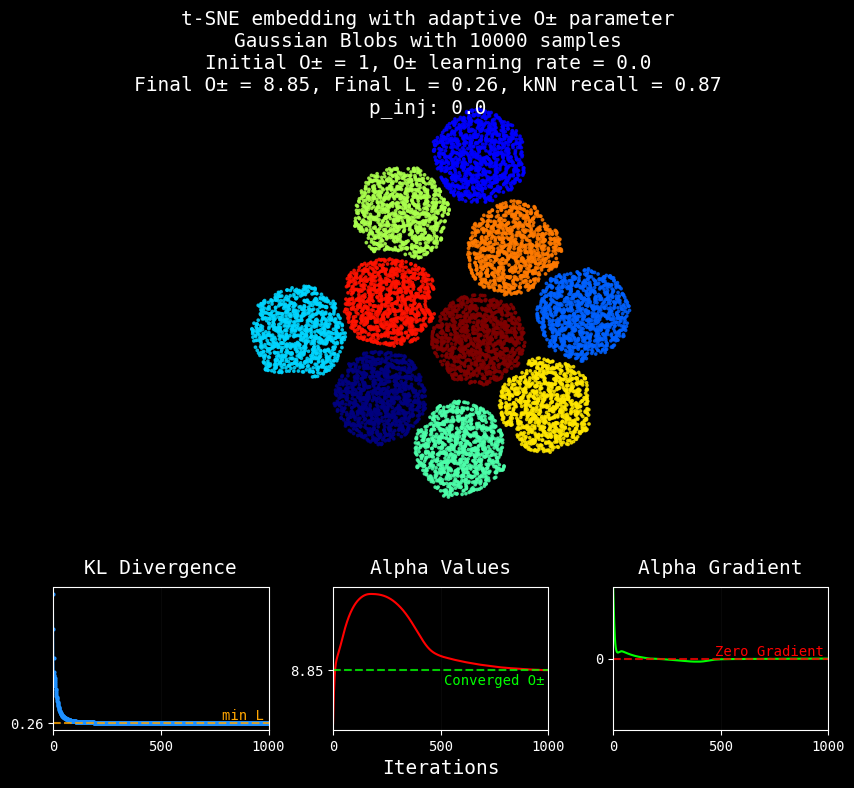

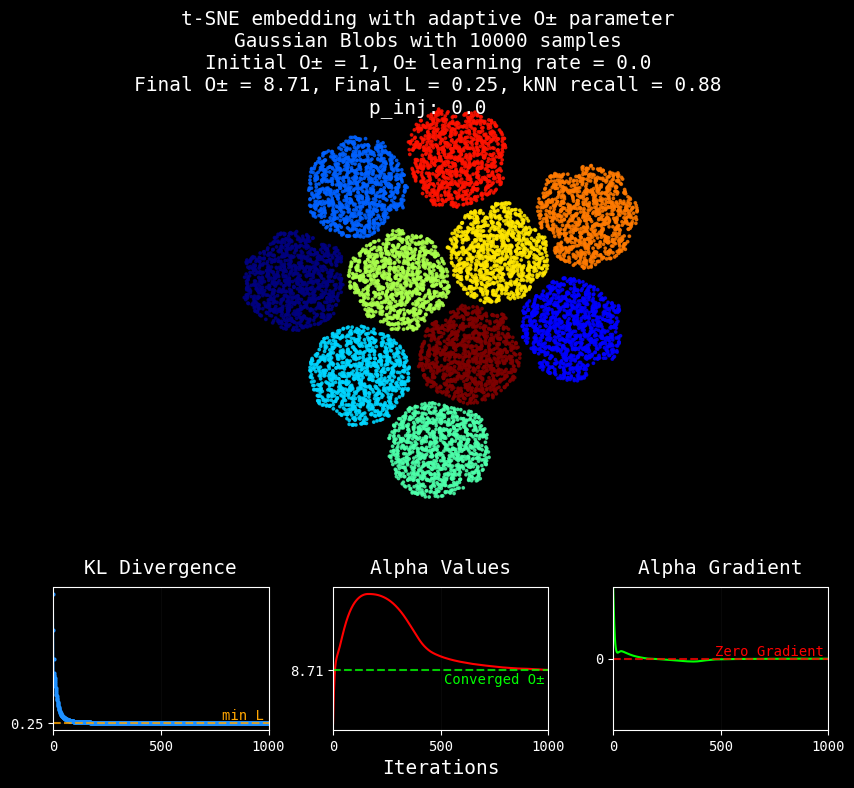

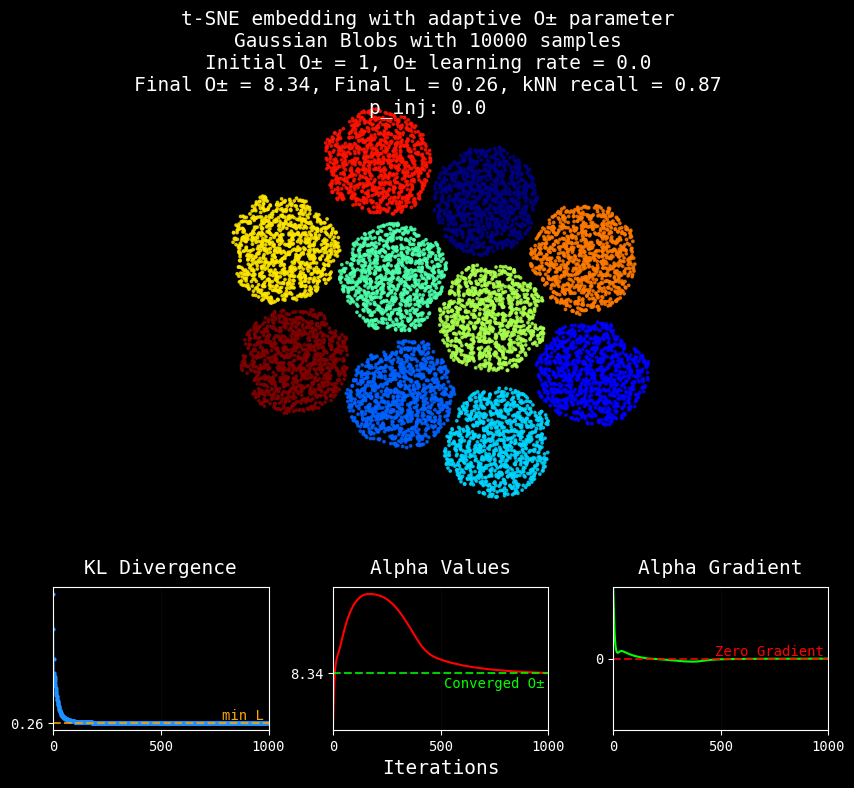

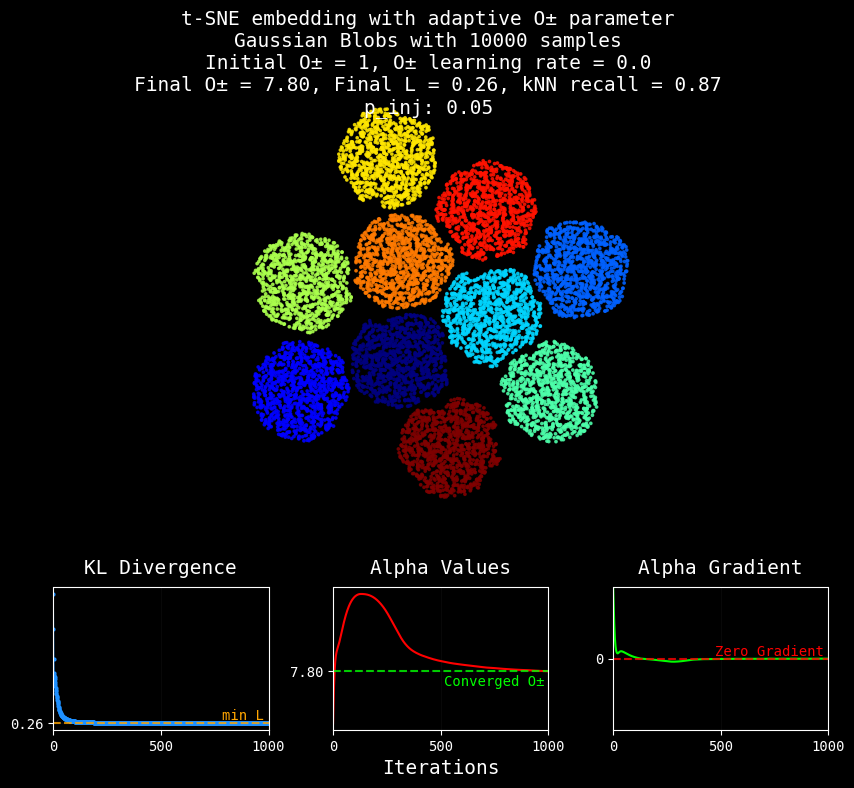

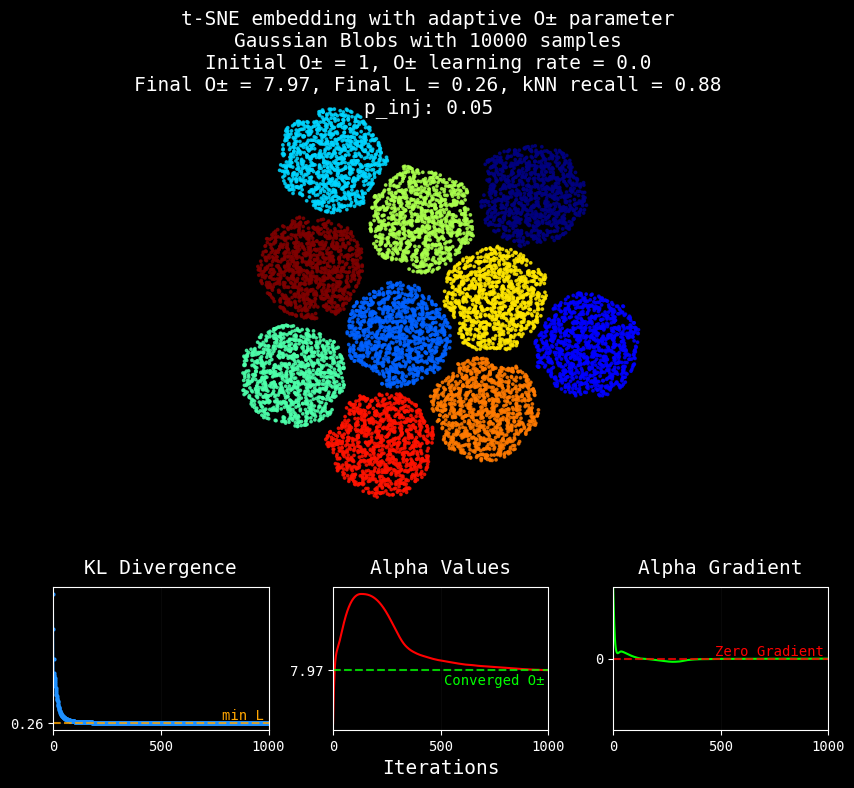

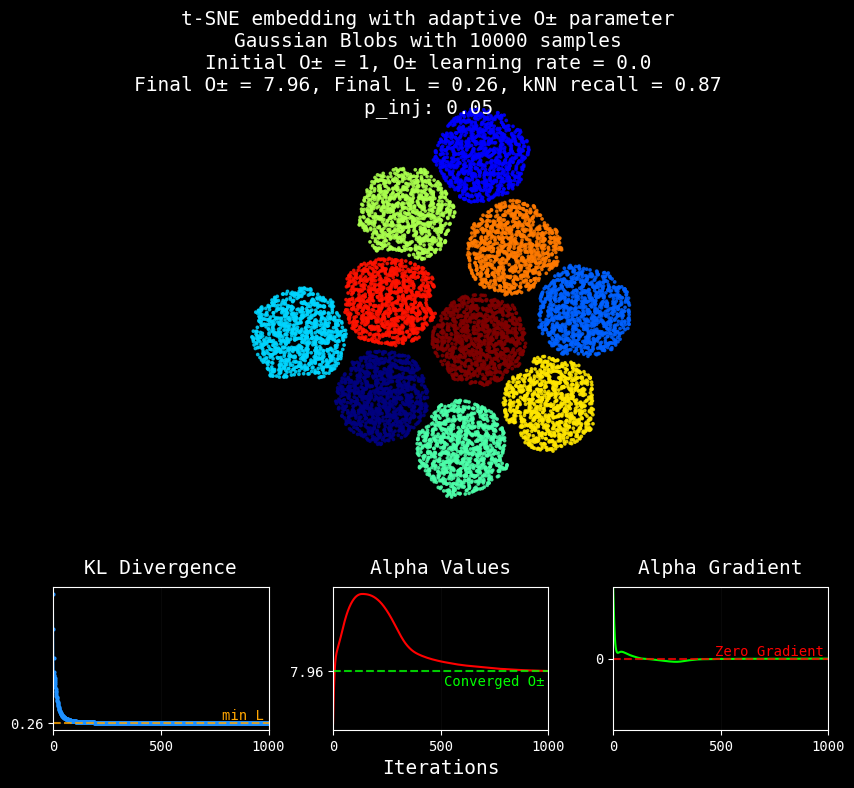

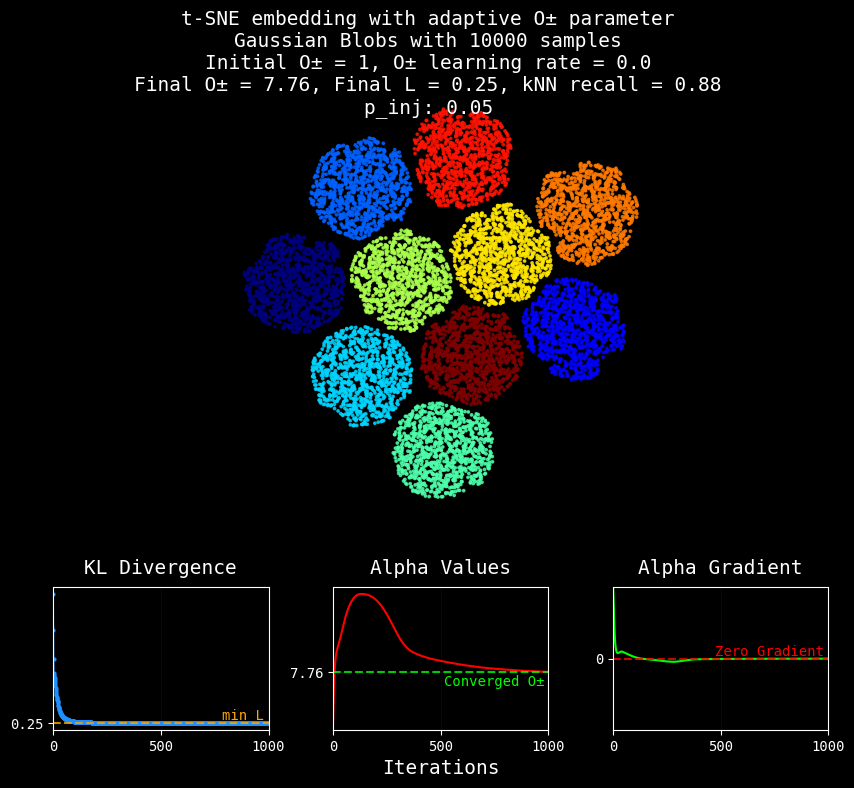

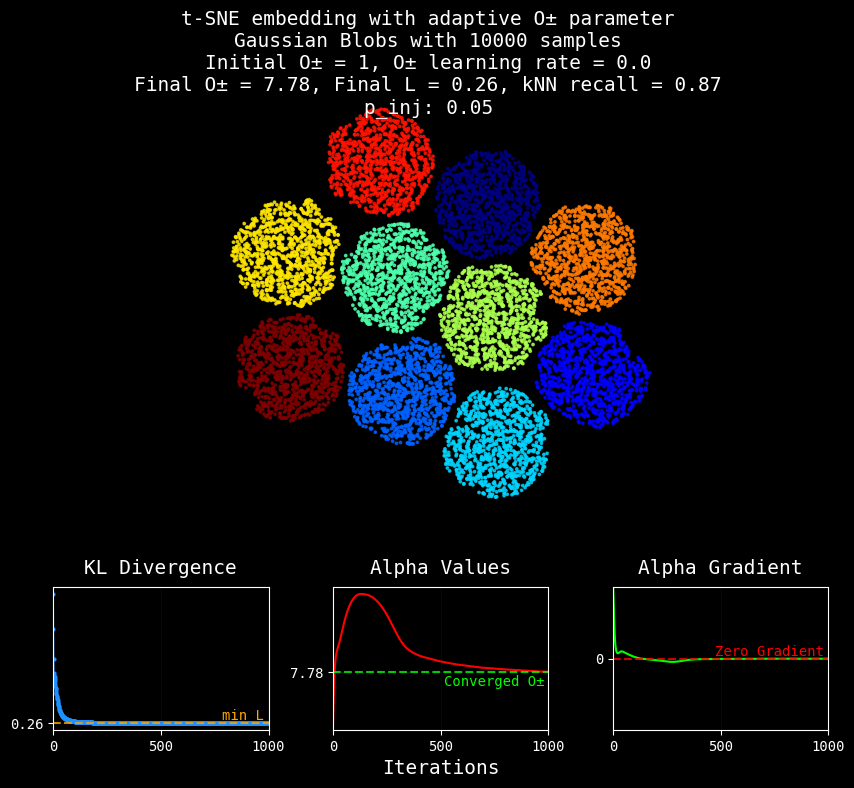

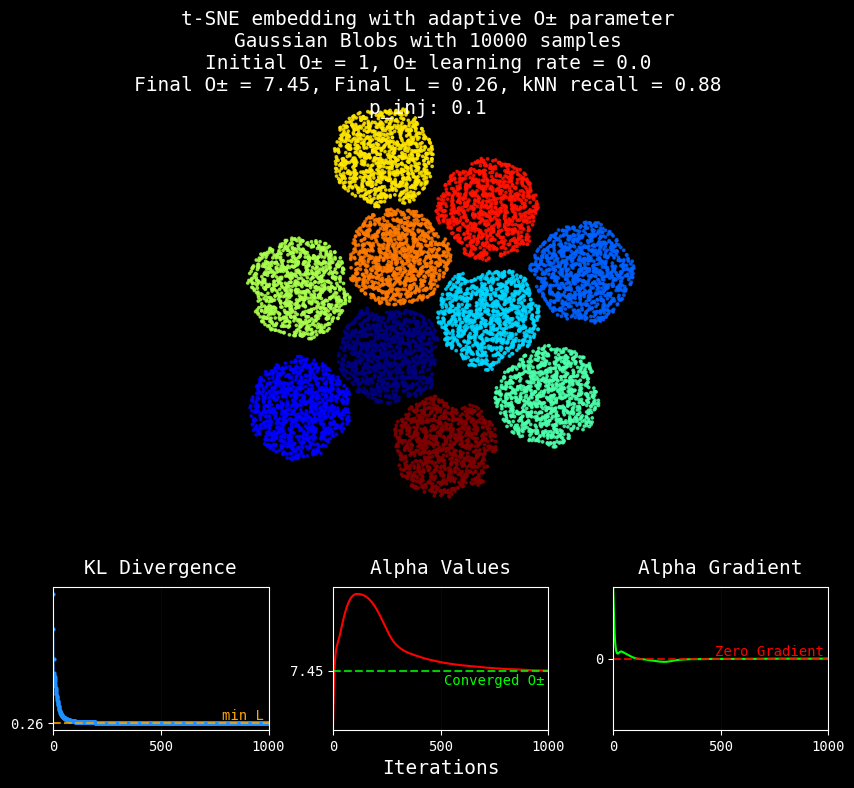

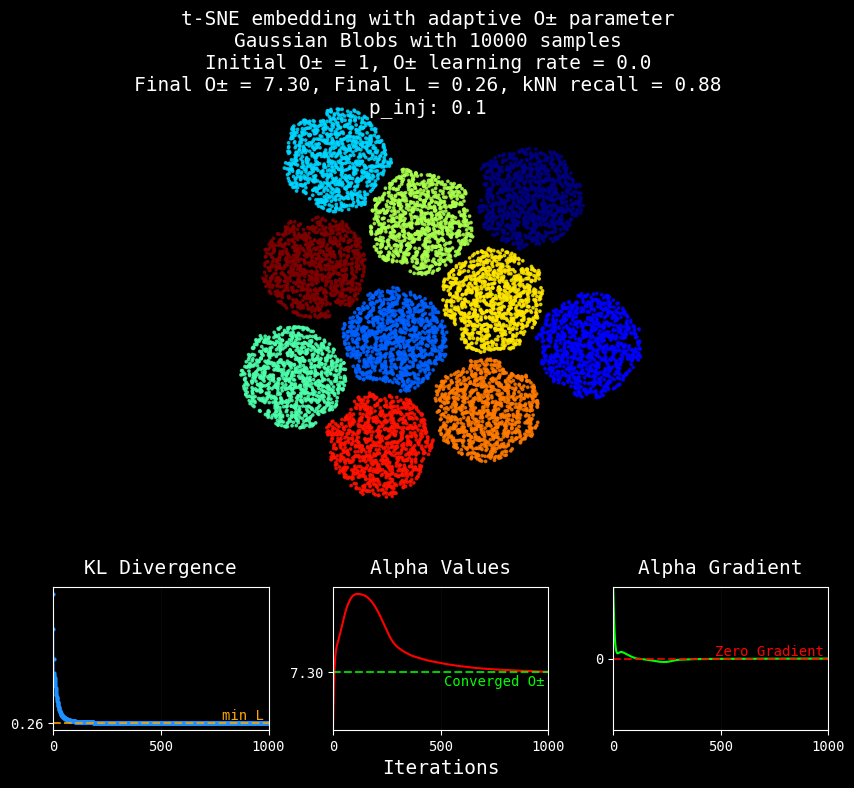

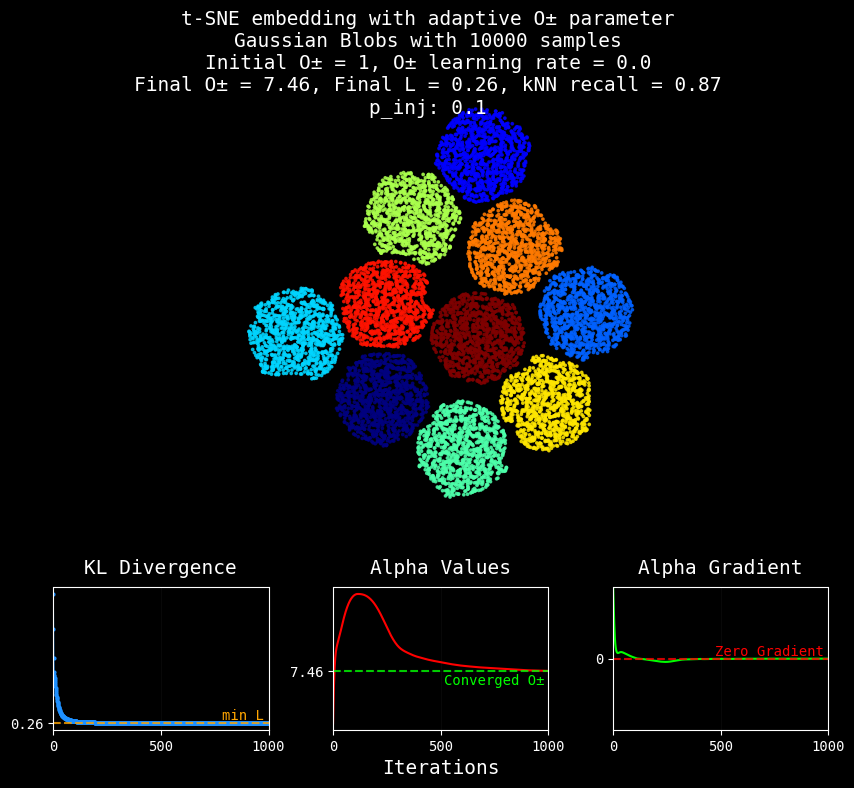

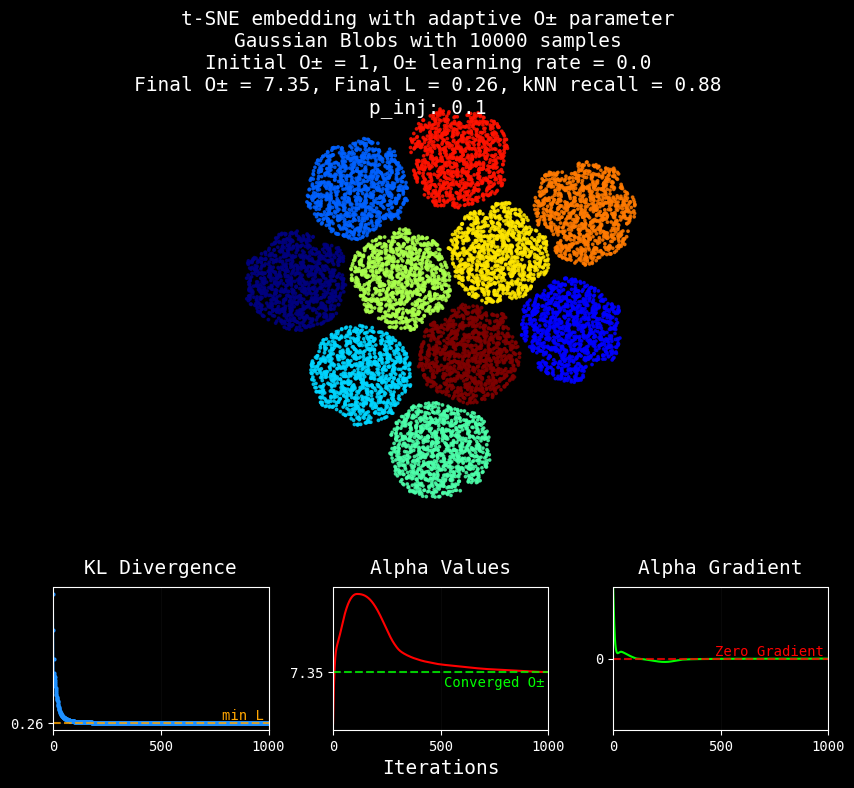

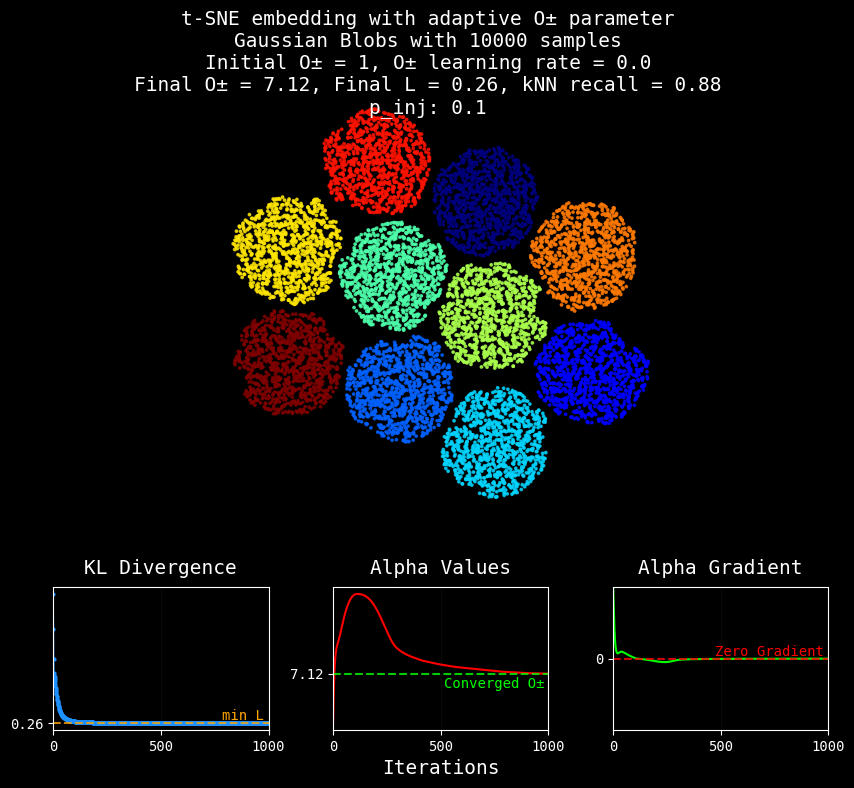

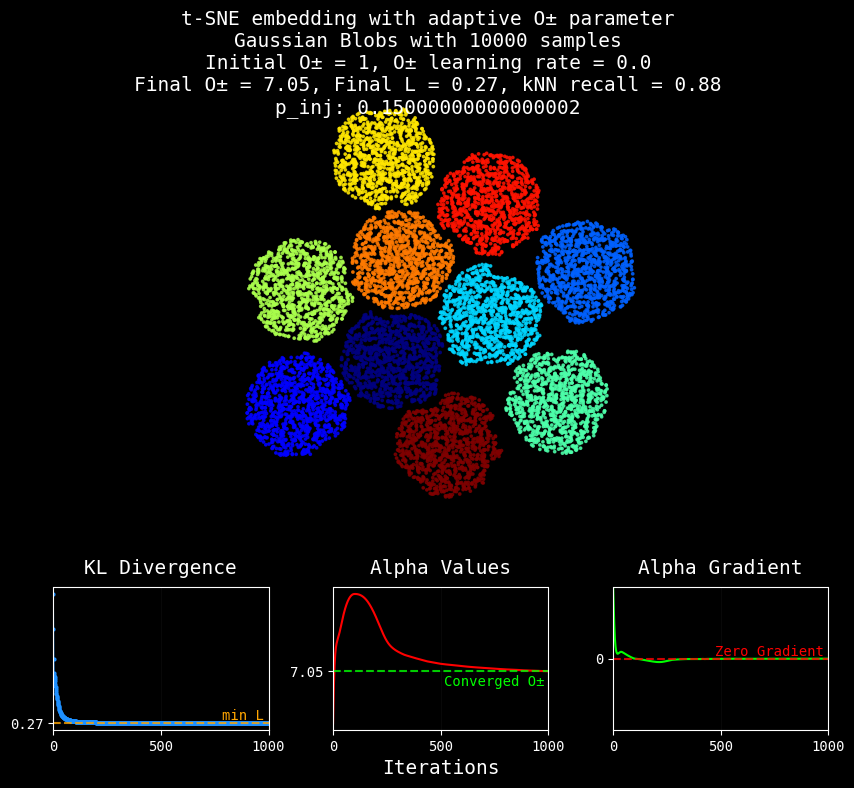

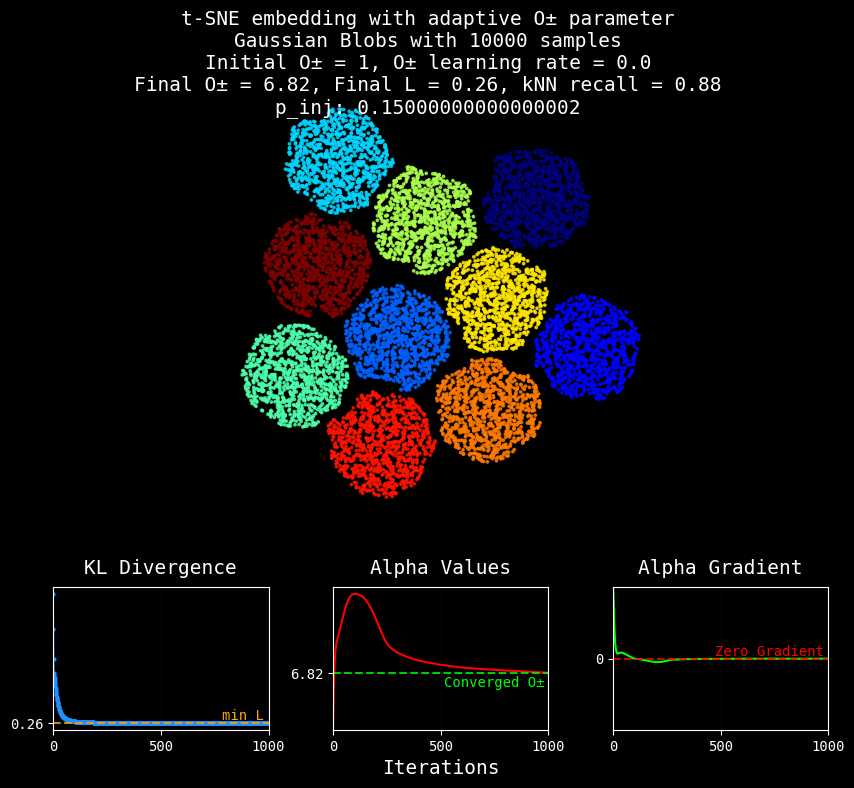

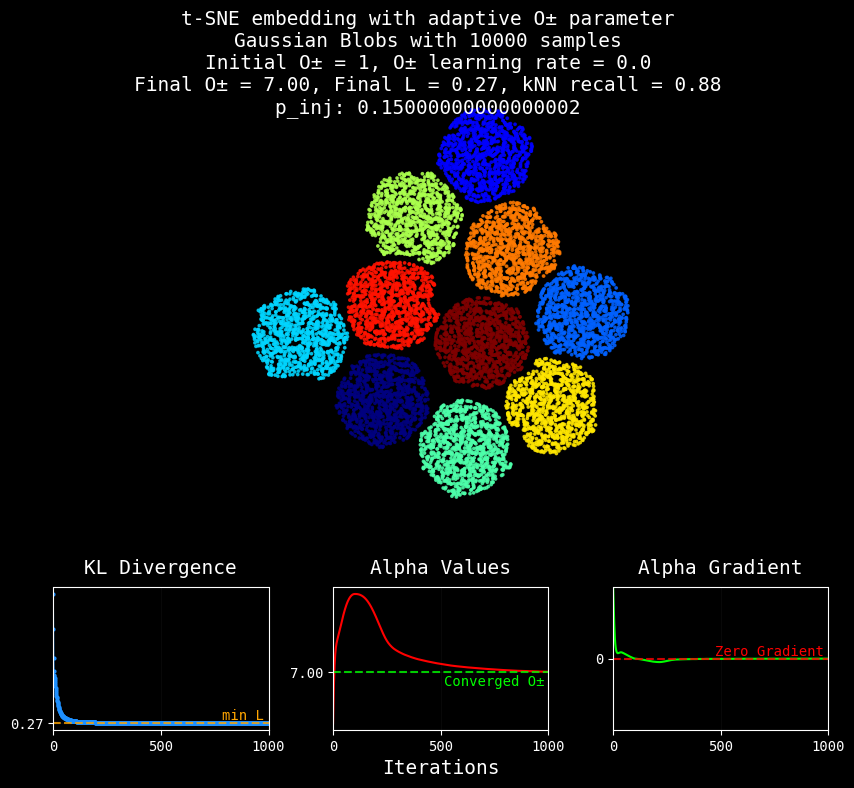

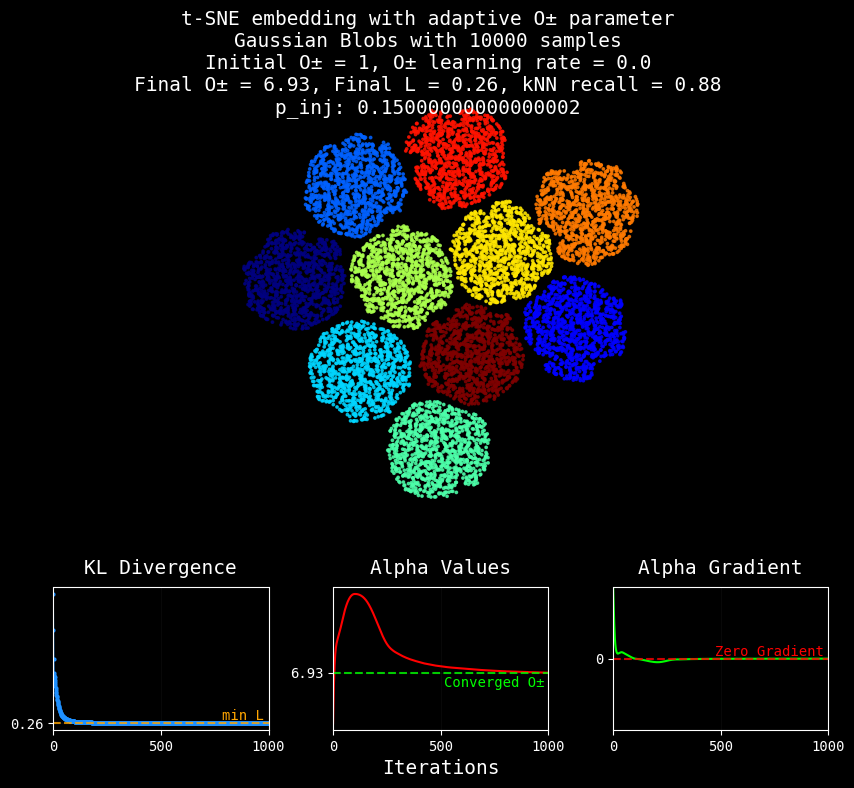

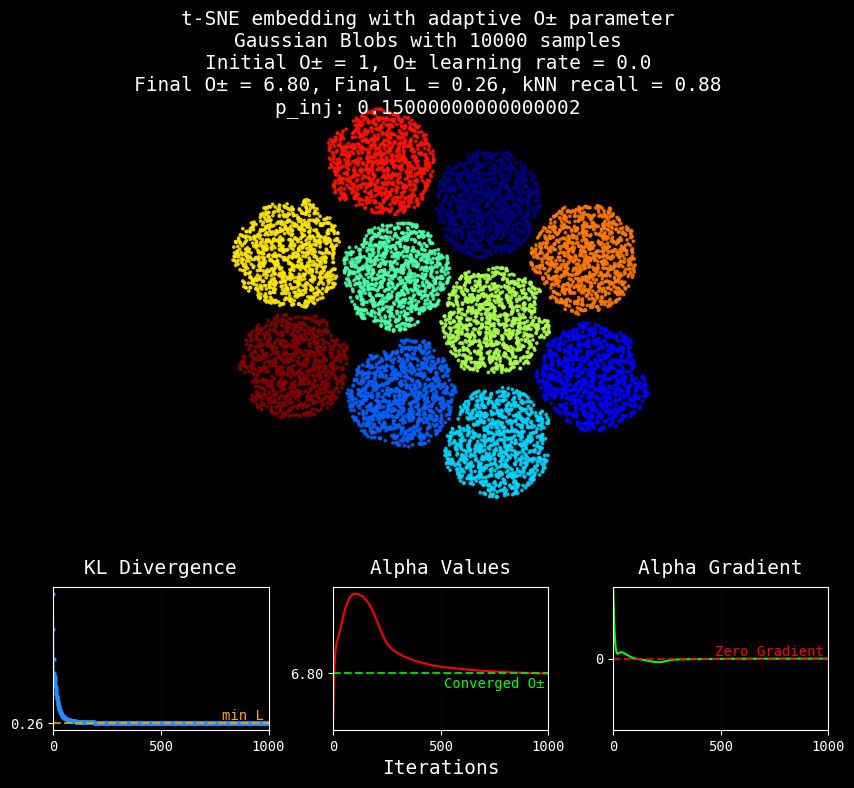

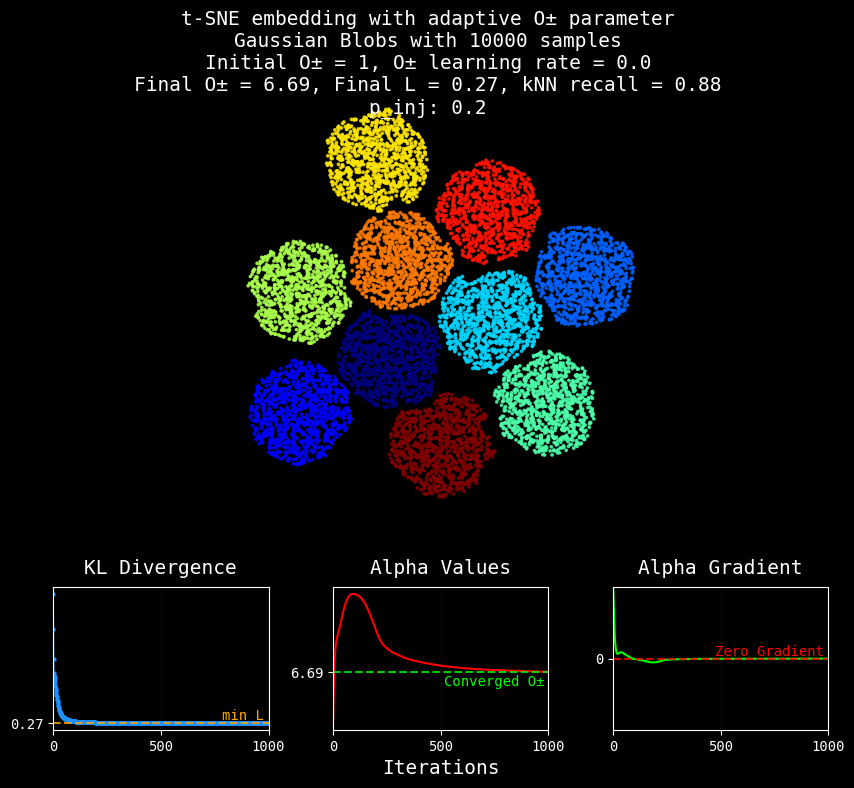

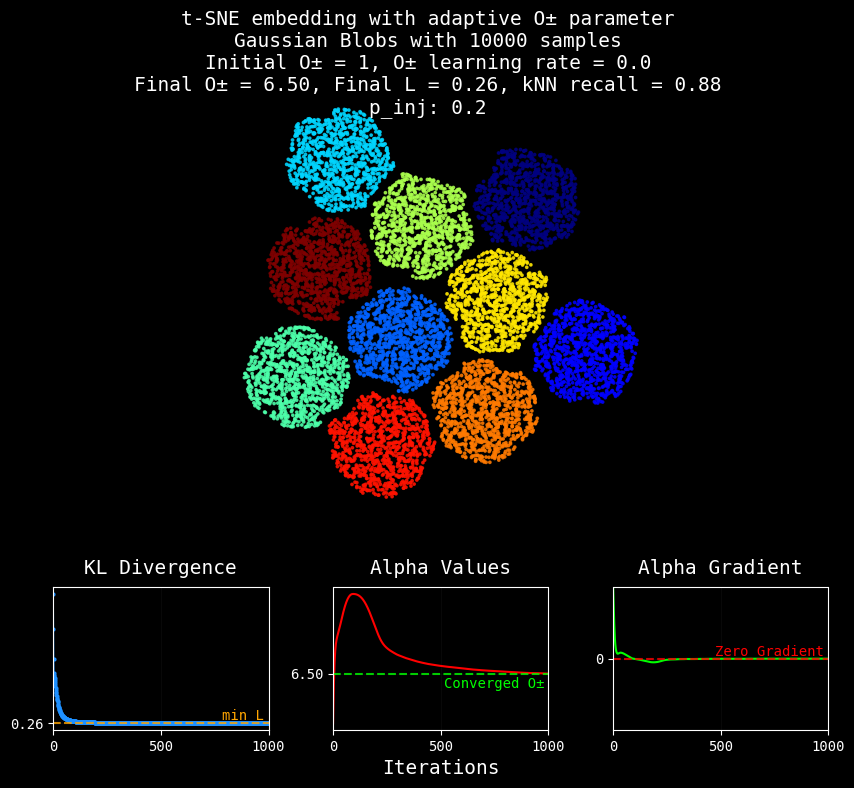

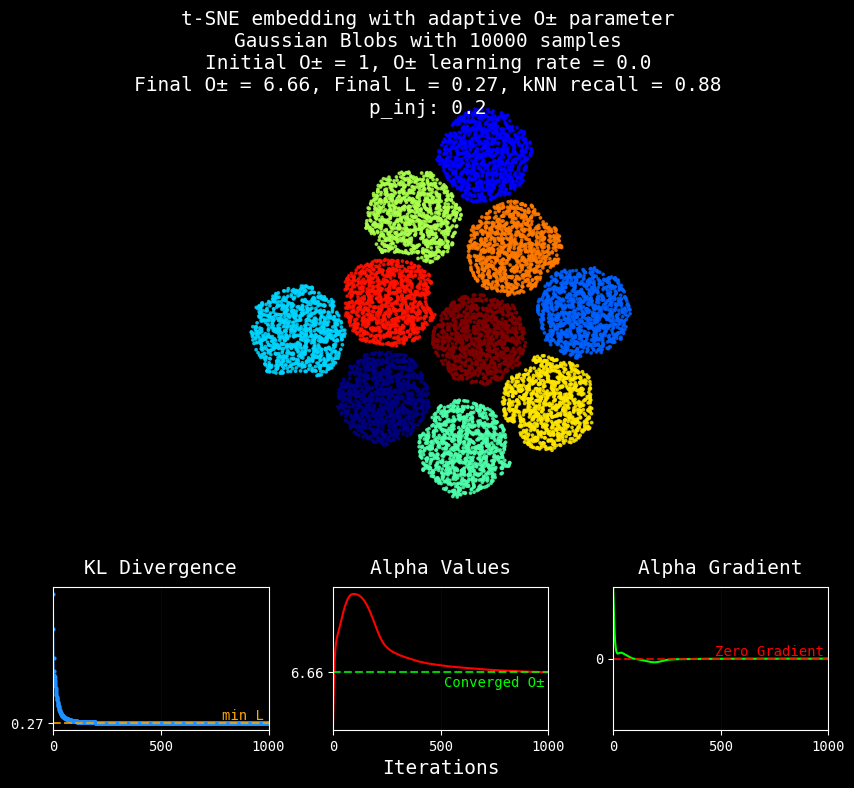

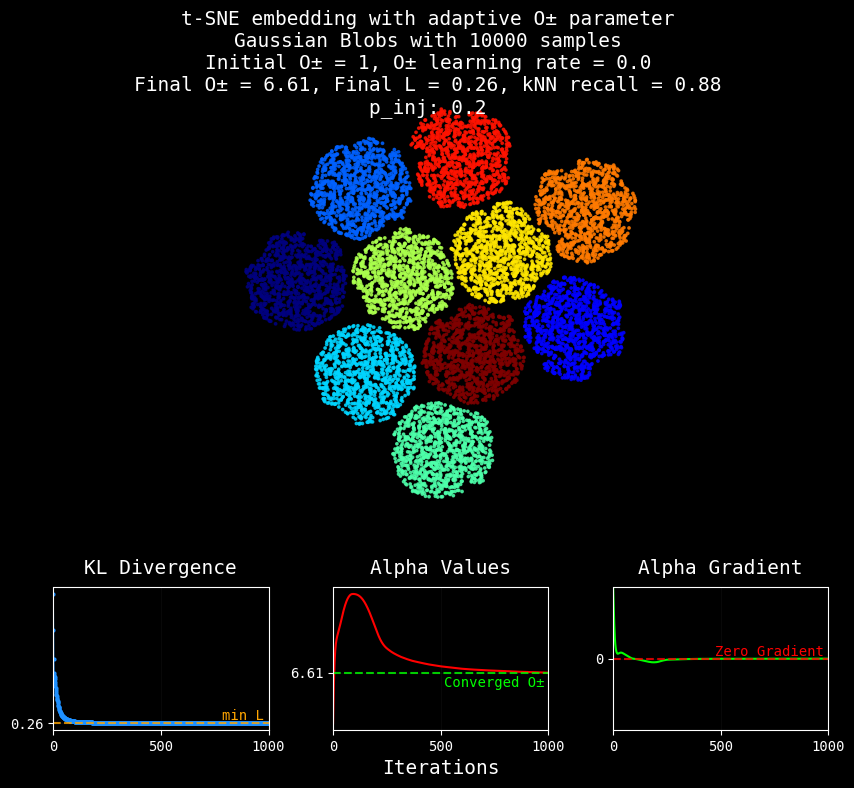

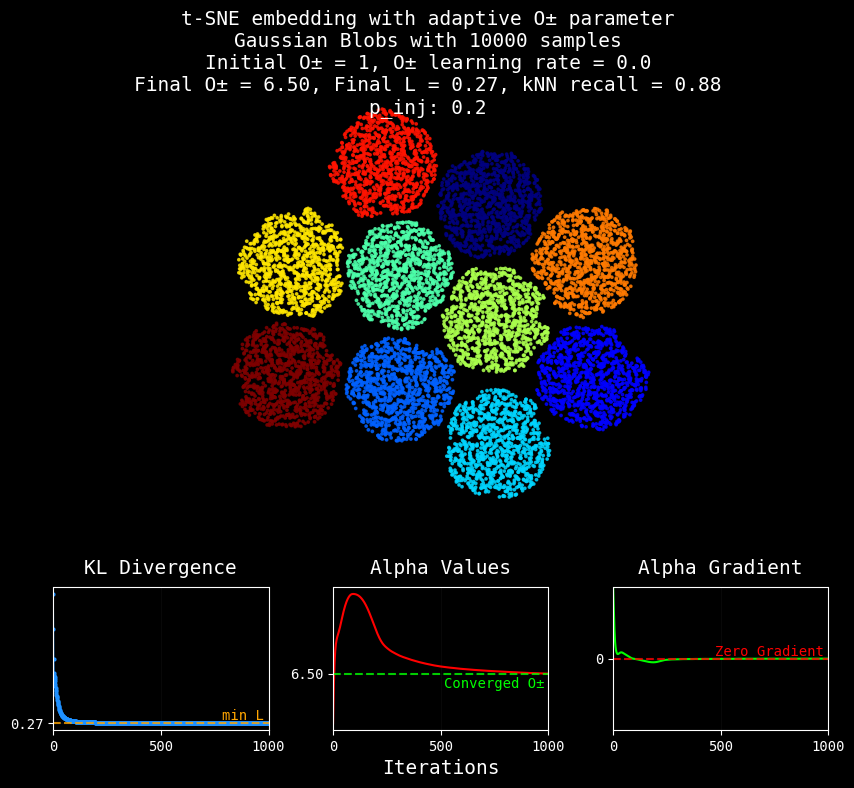

In [95]:
base_results_path = Path("fake_edges_experiment_results")

base_results_path.mkdir(exist_ok=True)
RESULTS = {}
n_dim = 2
for p_inj in np.arange(0, 0.25, 0.05):
    RESULTS.setdefault(f"p_{p_inj}", {})
    results_path = base_results_path / f"{p_inj}"
    results_path.mkdir(exist_ok=True)
    for run in range(5):
        RESULTS[f"p_{p_inj}"].setdefault(f"run_{run}", {})

        X, y, centers = generate_separated_gaussian_clusters(
            n_clusters=10,
            points_per_cluster=1000,
            dim=n_dim,
            sigma=sigma,
            q=q,
            seed=run,  # tie random seed to run for reproducibility
        )
        affinities_obj = PerplexityBasedNN(
            data=X,
            perplexity=perplexity,
            metric="euclidean",
            random_state=42,
        )
        P_clean = affinities_obj.P
        p_corr = inject_false_edges_into_P(P_clean, p_inject=p_inj, strength=1)
        pre_computed = make_precomputed_affinities(p_corr)
        tsne_result: TSNEResult = run_tsne(
            X,
            perplexity=perplexity,
            random_state=None,
            n_components=n_components,
            n_iter=n_iter,
            n_jobs=n_jobs,
            initial_dof=initial_alpha,
            dof="auto",
            negative_gradient_method="bh",
            dataset_name=dataset_name,
            affinities_type=affinities_type,
            pre_computed_affinities=pre_computed,
            verbose=True,
        )
        fig = plot_tsne_result(
            tsne_result,
            y,
            f"p_inj: {p_inj}",
            black_template=True,
            show_figure=False,
        )
        fig.savefig(results_path / f"run_{run}.png", dpi=300)
        # now write values
        RESULTS[f"p_{p_inj}"][f"run_{run}"]["optimal_dof"] = round(
            float(tsne_result.im_alphas[-1]), 4
        )
        RESULTS[f"p_{p_inj}"][f"run_{run}"]["KL"] = round(
            float(tsne_result.im_KLs[-1]), 4
        )
        RESULTS[f"p_{p_inj}"][f"run_{run}"]["alpha_grad"] = round(
            float(tsne_result.im_alpha_grads[-1]), 4
        )
        with Path(base_results_path / f"overall_results_fake_edges.json").open(
            "w"
        ) as f:
            json.dump(RESULTS, f, indent=4)

## Results

In [4]:
path = "fake_edges_experiment_results/overall_results_fake_edges.json"
with Path(path).open() as f:
    loaded_results = json.load(f)

Text(0, 0.5, 'Optimal DoF')

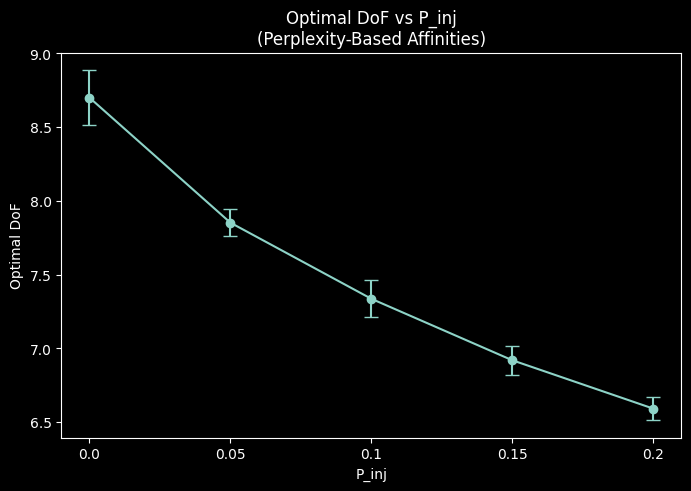

In [100]:
p_inj = np.arange(0, 0.25, 0.05)
runs = range(5)

optimal_dofs = [
    [loaded_results[f"p_{p}"][f"run_{run}"]["optimal_dof"] for run in runs]
    for p in p_inj
]

fig, ax = plt.subplots(figsize=(8, 5))
ax.errorbar(
    [str(round(p, 2)) for p in p_inj],
    [np.mean(optimal_dofs[i]) for i in range(len(p_inj))],
    yerr=[np.std(optimal_dofs[i]) for i in range(len(p_inj))],
    fmt="-o",
    capsize=5,
)
ax.set_title("Optimal DoF vs P_inj\n(Perplexity-Based Affinities)")
ax.set_xlabel("P_inj")
ax.set_ylabel("Optimal DoF")

Text(0, 0.5, 'KL Divergence')

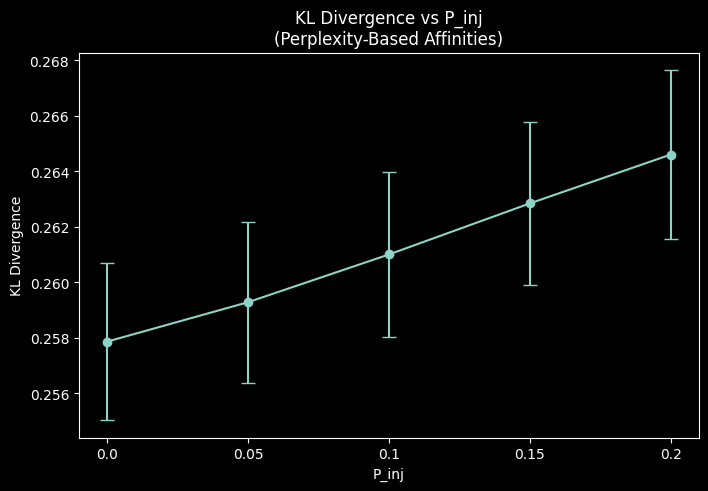

In [ ]:
p_inj = np.arange(0, 0.25, 0.05)
runs = range(5)

kl_values = [
    [loaded_results[f"p_{p}"][f"run_{run}"]["KL"] for run in runs] for p in p_inj
]

fig, ax = plt.subplots(figsize=(8, 5))
ax.errorbar(
    [str(round(p, 2)) for p in p_inj],
    [np.mean(kl_values[i]) for i in range(len(p_inj))],
    yerr=[np.std(kl_values[i]) for i in range(len(p_inj))],
    fmt="-o",
    capsize=5,
)
ax.set_title("KL Divergence vs P_inj\n(Perplexity-Based Affinities)")
ax.set_xlabel("P_inj")
ax.set_ylabel("KL Divergence")